In [1]:
import functions as fn
from mastu import HSV
import matplotlib.pyplot as plt
import my_funcs as mf
import numpy as np
import pyuda
client = pyuda.Client()
from scipy.interpolate import interp2d
import sys

kk_cz couldnt be imported
dd couldnt be imported


In [2]:
from scipy.optimize import curve_fit

In [3]:
%matplotlib widget

In [4]:
shotn = 50499
twant = 0.5

In [5]:
def mtanh(R, R0, height, width, grad, bkgd):
    ###
    z = -4. * (R - R0) / width
    L = 1. / (1. + np.exp(-z))
    profile = (L * (height - bkgd + ((z * width * grad) / 4.))) + bkgd
    return profile

/tmp/ipykernel_8018/2212370597.py:94: OptimizeWarning: Covariance of the parameters could not be estimated
  poptPe, pcovPe = curve_fit(


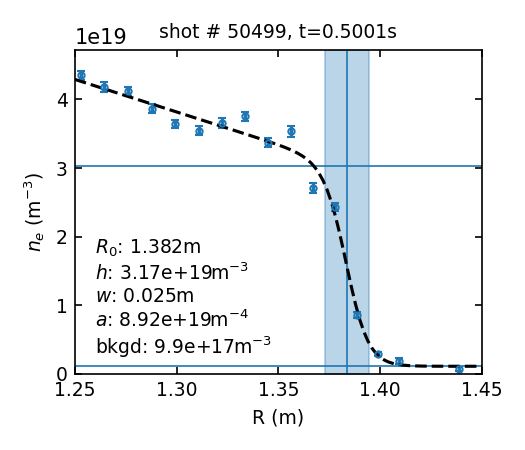

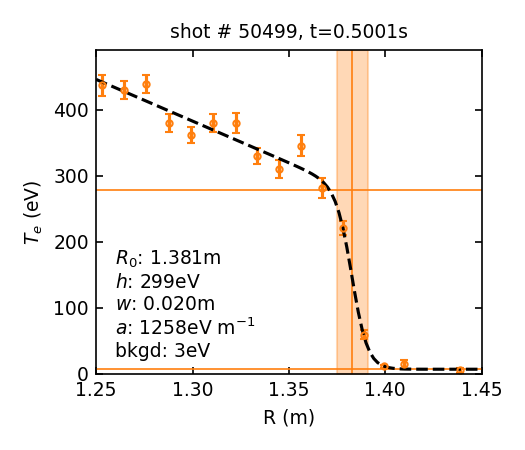

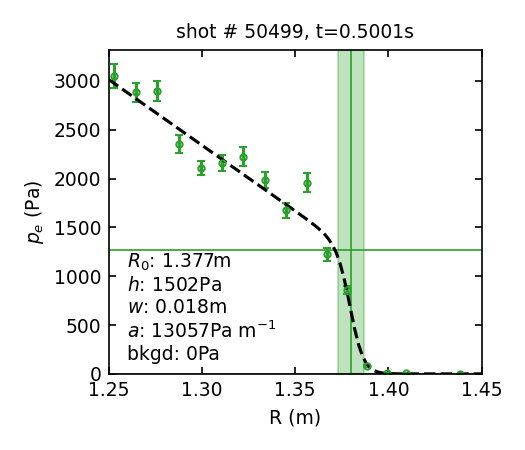

In [6]:
R0 = 1.25 # where the fit should be valid to
R1 = 1.45 # for the plots
R = np.linspace(R0, R1, 101)
y0 = 0.
yMult = 1.1 # for the ylim in the plots
dR = 0.01
dyDensity = 0.2e19
dyTemp = 20.
dyPressure = 100.


timePed = client.get('/apf/core/mtanh/lfs/time', shotn).data
tind = HSV.findNearest(timePed, twant)


R0Density = client.get('/apf/core/mtanh/lfs/n_e/pedestal_location', shotn).data[tind]
heightDensity = client.get('/apf/core/mtanh/lfs/n_e/pedestal_height', shotn).data[tind]
widthDensity = client.get('/apf/core/mtanh/lfs/n_e/pedestal_width', shotn).data[tind]
gradDensity = client.get('/apf/core/mtanh/lfs/n_e/pedestal_top_gradient', shotn).data[tind]
bkgdDensity = client.get('/apf/core/mtanh/lfs/n_e/background_level', shotn).data[tind]
paramsDensity = (
    R0Density, heightDensity, widthDensity, gradDensity, bkgdDensity
)
textDensity = f'\
$R_0$: {R0Density:.3f}m\n\
$h$: {heightDensity:.3g}m$^{{-3}}$\n\
$w$: {widthDensity:.3f}m\n\
$a$: {gradDensity:.3g}m$^{{-4}}$\n\
bkgd: {bkgdDensity:.3g}m$^{{-3}}$'

R0Temp = client.get('/apf/core/mtanh/lfs/T_e/pedestal_location', shotn).data[tind]
heightTemp = client.get('/apf/core/mtanh/lfs/T_e/pedestal_height', shotn).data[tind]
widthTemp = client.get('/apf/core/mtanh/lfs/T_e/pedestal_width', shotn).data[tind]
gradTemp = client.get('/apf/core/mtanh/lfs/T_e/pedestal_top_gradient', shotn).data[tind]
bkgdTemp = client.get('/apf/core/mtanh/lfs/T_e/background_level', shotn).data[tind]
paramsTemp = (
    R0Temp, heightTemp, widthTemp, gradTemp, bkgdTemp
)
textTemp = f'\
$R_0$: {R0Temp:.3f}m\n\
$h$: {heightTemp:.0f}eV\n\
$w$: {widthTemp:.3f}m\n\
$a$: {gradTemp:.0f}eV m$^{{-1}}$\n\
bkgd: {bkgdTemp:.0f}eV'

R0Pressure = client.get('/apf/core/mtanh/lfs/p_e/pedestal_location', shotn).data[tind]
heightPressure = client.get('/apf/core/mtanh/lfs/p_e/pedestal_height', shotn).data[tind]
widthPressure = client.get('/apf/core/mtanh/lfs/p_e/pedestal_width', shotn).data[tind]
gradPressure = client.get('/apf/core/mtanh/lfs/p_e/pedestal_top_gradient', shotn).data[tind]
bkgdPressure = client.get('/apf/core/mtanh/lfs/p_e/background_level', shotn).data[tind]
paramsPressure = (
    R0Pressure, heightPressure, widthPressure, gradPressure, bkgdPressure
)
textPressure = f'\
$R_0$: {R0Pressure:.3f}m\n\
$h$: {heightPressure:.0f}Pa\n\
$w$: {widthPressure:.3f}m\n\
$a$: {gradPressure:.0f}Pa m$^{{-1}}$\n\
bkgd: {bkgdPressure:.0f}Pa'


timeThomson = client.get('/ayc/time', shotn).data
tind0 = mf.find_nearest(timeThomson, twant)


ne, neErr, RThomson = mf.getNe(shotn)
RThomson = RThomson[tind0]
Rind = HSV.findNearest(RThomson, R0)
ne = ne.data[tind0,Rind:]
neErr = neErr[tind0,Rind:]

Te, TeErr, _ = mf.getTe(shotn)
Te = Te.data[tind0,Rind:]
TeErr = TeErr[tind0,Rind:]

Pe, PeErr, _ = mf.getPe(shotn)
Pe = Pe.data[tind0,Rind:]
PeErr = PeErr[tind0,Rind:]

boone = np.isfinite(ne)
booTe = np.isfinite(Te)
booPe = np.isfinite(Pe)

poptne, pcovne = curve_fit(
    mtanh, RThomson[Rind:][boone], ne[boone], sigma=neErr[boone], 
    absolute_sigma=True, p0=paramsDensity
)
pcovne = np.sqrt(np.diag(pcovne))
poptTe, pcovTe = curve_fit(
    mtanh, RThomson[Rind:][booTe], Te[booTe], sigma=TeErr[booTe], 
    absolute_sigma=True, p0=paramsTemp
)
pcovTe = np.sqrt(np.diag(pcovTe))
poptPe, pcovPe = curve_fit(
    mtanh, RThomson[Rind:][booPe], Pe[booPe], sigma=PeErr[booPe], 
    absolute_sigma=True, p0=paramsPressure
)
pcovPe = np.sqrt(np.diag(pcovPe))


profileDensity = mtanh(R, *poptne)
y1Density = profileDensity[0] * yMult
profileTemp = mtanh(R, *poptTe)
y1Temp = profileTemp[0] * yMult
profilePressure = mtanh(R, *poptPe)
y1Pressure = profilePressure[0] * yMult

###R0, height, width, grad, bkgd

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.plot([R0, R1], [poptne[1], poptne[1]], '-', c='C0', lw=0.8)
ax.plot([R0, R1], [poptne[4], poptne[4]], '-', c='C0', lw=0.8)
ax.plot([poptne[0], poptne[0]], [y0, y1Density], '-', c='C0', lw=0.8)
ax.fill_between(
    [poptne[0]-poptne[2]*0.5, poptne[0]+poptne[2]*0.5], 
    [y0, y0], [y1Density, y1Density], color='C0', alpha=0.3, 
)
ax.errorbar(RThomson[Rind:], ne, yerr=neErr, fmt='.', c='C0', mfc='None', capsize=2)
ax.plot(R, profileDensity, '--k')
ax.set_xlim([R0, R1])
ax.set_ylim([y0, y1Density])
ax.set_xlabel('R (m)', fontsize=9)
ax.set_ylabel('$n_e$ (m$^{-3}$)', fontsize=9)
ax.tick_params(axis="both", which='both', labelsize=9, direction='in', 
              left=True, bottom=True, right=True, top=True)
ax.set_title(f'shot # {shotn:.0f}, t={timePed[tind]:.4f}s', fontsize=9)
ax.text(R0+dR, y0+dyDensity, textDensity, ha='left', va='bottom', fontsize=9)
plt.tight_layout()

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.plot([R0, R1], [poptTe[1], poptTe[1]], '-', c='C1', lw=0.8)
ax.plot([R0, R1], [poptTe[4], poptTe[4]], '-', c='C1', lw=0.8)
ax.plot([poptTe[0], poptTe[0]], [y0, y1Temp], '-', c='C1', lw=0.8)
ax.fill_between(
    [poptTe[0]-poptTe[2]*0.5, poptTe[0]+poptTe[2]*0.5], 
    [y0, y0], [y1Temp, y1Temp], color='C1', alpha=0.3, 
)
ax.errorbar(RThomson[Rind:], Te, yerr=TeErr, fmt='.', c='C1', mfc='None', capsize=2)
ax.plot(R, profileTemp, '--k')
ax.set_xlim([R0, R1])
ax.set_ylim([y0, y1Temp])
ax.set_xlabel('R (m)', fontsize=9)
ax.set_ylabel('$T_e$ (eV)', fontsize=9)
ax.tick_params(axis="both", which='both', labelsize=9, direction='in', 
              left=True, bottom=True, right=True, top=True)
ax.set_title(f'shot # {shotn:.0f}, t={timePed[tind]:.4f}s', fontsize=9)
ax.text(R0+dR, y0+dyTemp, textTemp, ha='left', va='bottom', fontsize=9)
plt.tight_layout()

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.plot([R0, R1], [poptPe[1], poptPe[1]], '-', c='C2', lw=0.8)
ax.plot([R0, R1], [poptPe[4], poptPe[4]], '-', c='C2', lw=0.8)
ax.plot([poptPe[0], poptPe[0]], [y0, y1Pressure], '-', c='C2', lw=0.8)
ax.fill_between(
    [poptPe[0]-poptPe[2]*0.5, poptPe[0]+poptPe[2]*0.5], 
    [y0, y0], [y1Pressure, y1Pressure], color='C2', alpha=0.3, 
)
ax.errorbar(RThomson[Rind:], Pe, yerr=PeErr, fmt='.', c='C2', mfc='None', capsize=2)
ax.plot(R, profilePressure, '--k')
ax.set_xlim([R0, R1])
ax.set_ylim([y0, y1Pressure])
ax.set_xlabel('R (m)', fontsize=9)
ax.set_ylabel('$p_e$ (Pa)', fontsize=9)
ax.tick_params(axis="both", which='both', labelsize=9, direction='in', 
              left=True, bottom=True, right=True, top=True)
ax.set_title(f'shot # {shotn:.0f}, t={timePed[tind]:.4f}s', fontsize=9)
ax.text(R0+dR, y0+dyPressure, textPressure, ha='left', va='bottom', fontsize=9)
plt.tight_layout()

In [7]:
excit = np.load('/home/sthoma/tokamak_inversion_routines/ADAS/EXCIT_pec12#h_pju#h0.npz')
ne0 = excit['ne'][13:20]
Te0 = excit['Te'][4:23]
dataExcite = excit['data'][13:20,4:23]
### units of [ph m^3 /s]
recom = np.load('/home/sthoma/tokamak_inversion_routines/ADAS/RECOM_pec12#h_pju#h0.npz')
dataRecomb = recom['data'][13:20,4:23]
### units of [ph m^3 /s]
# ionis = np.load('/home/sthoma/tokamak_inversion_routines/ADAS/IONIS_scd12h.npz')
ionis = np.load('/home/sthoma/tokamak_inversion_routines/ADAS/IONIS_scd12h_ver2.npz')
dataIonise = ionis['data'][13:20,4:23]
### units of [m^3 /s]

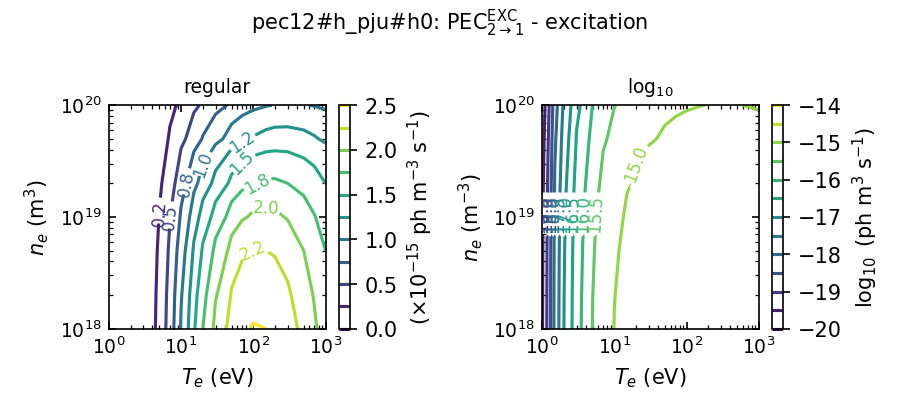

In [8]:
cmap=plt.cm.viridis

fig, ax = plt.subplots(1, 2, figsize=(6,2.75), dpi=150)


N = 15
levels = np.linspace(0., 2.5e-15*(10**N), 11)
cf = ax[0].contour(Te0, ne0, dataExcite*(10**N), levels, cmap=cmap)
fig.colorbar(
    cf, ax=ax[0], ticks=levels[::2], 
    label=f'($\\times10^{{{-N:.0f}}}$ ph m$^{{-3}}$ s$^{{-1}}$)'
)
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].clabel(
    cf, inline=1, fontsize=8, fmt='%1.1f', inline_spacing=5, use_clabeltext=False
)
ax[0].set_xlabel('$T_e$ (eV)')
ax[0].set_ylabel('$n_e$ (m$^3$)')
ax[0].set_xlim([1e0,1e3])
ax[0].set_ylim([1e18,1e20])
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].set_title('regular', fontsize=9)


levels = np.linspace(-20, -14, 13)
cf = ax[1].contour(Te0, ne0, np.log10(dataExcite), levels, cmap=cmap)
fig.colorbar(
    cf, ax=ax[1], ticks=levels[::2], 
    label='$\\log_{10}$ (ph m$^3$ s$^{-1}$)'
)
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].clabel(
    cf, inline=1, fontsize=8, fmt='%1.1f', inline_spacing=10, use_clabeltext=False
)
ax[1].set_xlabel('$T_e$ (eV)')
ax[1].set_ylabel('$n_e$ (m$^{-3}$)')
ax[1].set_xlim([1e0,1e3])
ax[1].set_ylim([1e18,1e20])
ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].set_title('$\\log_{10}$', fontsize=9)

fig.suptitle('pec12#h_pju#h0: PEC$^\\mathrm{EXC}_{2 \\rightarrow 1}$ - excitation', fontsize=10)
plt.tight_layout()

/tmp/ipykernel_8018/2203858808.py:2: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For scattered data, prefer `LinearNDInterpolator` or
`CloughTocher2DInterpolator`.

For more details see
`https://scipy.github.io/devdocs/notebooks/interp_transition_guide.html`

  fExciteLinear = interp2d(Te0, ne0, dataExcite, kind='linear', bounds_error=True)
/tmp/ipykernel_8018/2203858808.py:3: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For scattered data, pref

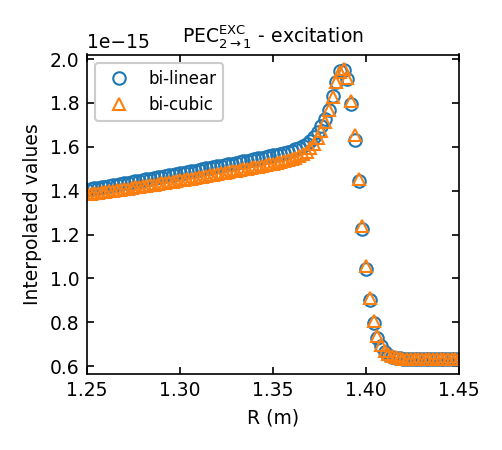

In [9]:
### excitation
fExciteLinear = interp2d(Te0, ne0, dataExcite, kind='linear', bounds_error=True)
fExciteCubic = interp2d(Te0, ne0, dataExcite, kind='cubic', bounds_error=True)

exciteLinear = np.diag(fExciteLinear(profileTemp, profileDensity))[::-1]
exciteCubic = np.diag(fExciteCubic(profileTemp, profileDensity))[::-1]


fig, ax = plt.subplots(1, 1, figsize=(3.35,3), dpi=150)
ax.plot(R, exciteLinear, 'o', c='C0', mfc='None', label='bi-linear')
ax.plot(R, exciteCubic, '^', c='C1', mfc='None', label='bi-cubic')
ax.set_title('PEC$^\\mathrm{EXC}_{2 \\rightarrow 1}$ - excitation', fontsize=9)
ax.legend(fancybox=1, framealpha=1, fontsize=8)
ax.set_xlabel('R (m)', fontsize=9)
ax.set_ylabel('Interpolated values', fontsize=9)
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.yaxis.get_offset_text().set_size(9)
ax.set_xlim([R0, R1])
plt.tight_layout()

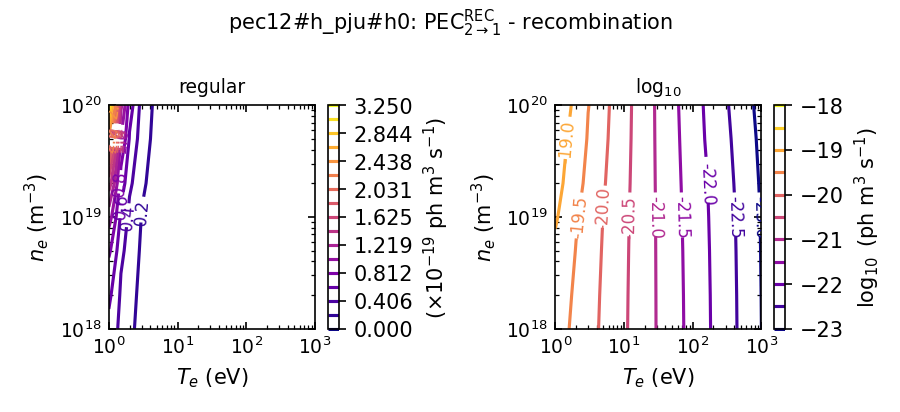

In [10]:
cmap=plt.cm.plasma

fig, ax = plt.subplots(1, 2, figsize=(6,2.75), dpi=150)


N = 19
levels = np.linspace(0., 3.25e-19*(10**N), 17)
cf = ax[0].contour(Te0, ne0, dataRecomb*(10**N), levels, cmap=cmap)
fig.colorbar(
    cf, ax=ax[0], ticks=levels[::2], 
    label=f'($\\times10^{{{-N:.0f}}}$ ph m$^3$ s$^{{-1}}$)'
)
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].clabel(
    cf, inline=1, fontsize=8, fmt='%1.1f', inline_spacing=5, use_clabeltext=False
)
ax[0].set_xlabel('$T_e$ (eV)')
ax[0].set_ylabel('$n_e$ (m$^{-3}$)')
ax[0].set_xlim([1e0,1e3])
ax[0].set_ylim([1e18,1e20])
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].set_title('regular', fontsize=9)


levels = np.linspace(-23, -18, 11)
cf = ax[1].contour(Te0, ne0, np.log10(dataRecomb), levels, cmap=cmap)
fig.colorbar(
    cf, ax=ax[1], ticks=levels[::2], 
    label='$\\log_{10}$ (ph m$^3$ s$^{-1}$)'
)
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].clabel(
    cf, inline=1, fontsize=8, fmt='%1.1f', inline_spacing=10, use_clabeltext=False
)
ax[1].set_xlabel('$T_e$ (eV)')
ax[1].set_ylabel('$n_e$ (m$^{-3}$)')
ax[1].set_xlim([1e0,1e3])
ax[1].set_ylim([1e18,1e20])
ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].set_title('$\\log_{10}$', fontsize=9)

fig.suptitle('pec12#h_pju#h0: PEC$^\\mathrm{REC}_{2 \\rightarrow 1}$ - recombination', fontsize=10)
plt.tight_layout()

/tmp/ipykernel_8018/463335700.py:2: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For scattered data, prefer `LinearNDInterpolator` or
`CloughTocher2DInterpolator`.

For more details see
`https://scipy.github.io/devdocs/notebooks/interp_transition_guide.html`

  fRecombLinear = interp2d(Te0, ne0, dataRecomb, kind='linear', bounds_error=True)
/tmp/ipykernel_8018/463335700.py:3: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For scattered data, prefer

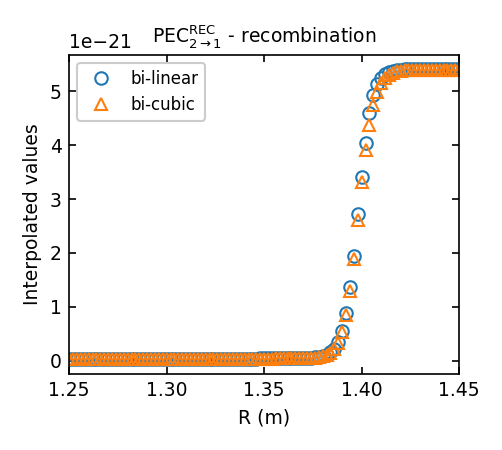

In [11]:
### recombination
fRecombLinear = interp2d(Te0, ne0, dataRecomb, kind='linear', bounds_error=True)
fRecombCubic = interp2d(Te0, ne0, dataRecomb, kind='cubic', bounds_error=True)

recombLinear = np.diag(fRecombLinear(profileTemp, profileDensity))[::-1]
recombCubic = np.diag(fRecombCubic(profileTemp, profileDensity))[::-1]


fig, ax = plt.subplots(1, 1, figsize=(3.35,3), dpi=150)
ax.plot(R, recombLinear, 'o', c='C0', mfc='None', label='bi-linear')
ax.plot(R, recombCubic, '^', c='C1', mfc='None', label='bi-cubic')
ax.set_title('PEC$^\\mathrm{REC}_{2 \\rightarrow 1}$ - recombination', fontsize=9)
ax.legend(fancybox=1, framealpha=1, fontsize=8)
ax.set_xlabel('R (m)', fontsize=9)
ax.set_ylabel('Interpolated values', fontsize=9)
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.yaxis.get_offset_text().set_size(9)
ax.set_xlim([R0, R1])
plt.tight_layout()

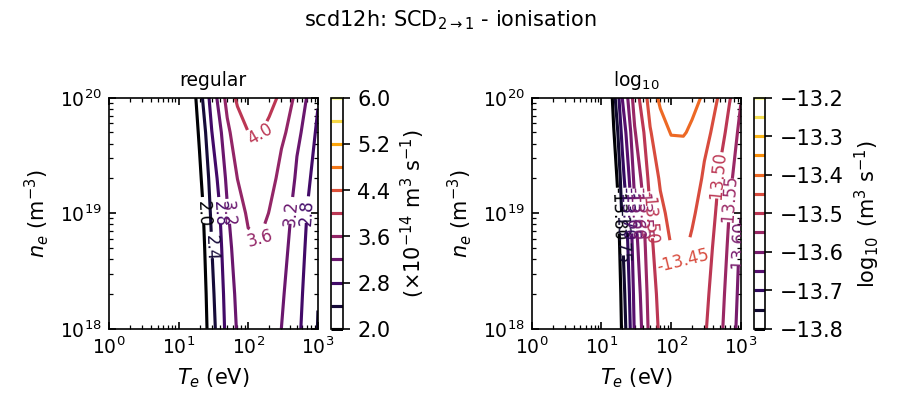

In [12]:
cmap=plt.cm.inferno

fig, ax = plt.subplots(1, 2, figsize=(6,2.75), dpi=150)


N = 14
levels = np.linspace(2e-14*(10**N), 6e-14*(10**N), 11)
cf = ax[0].contour(Te0, ne0, dataIonise*(10**N), levels, cmap=cmap)
fig.colorbar(
    cf, ax=ax[0], ticks=levels[::2], 
    label=f'($\\times10^{{{-N:.0f}}}$ m$^3$ s$^{{-1}}$)'
)
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].clabel(
    cf, inline=1, fontsize=8, fmt='%1.1f', inline_spacing=5, use_clabeltext=False
)
ax[0].set_xlabel('$T_e$ (eV)')
ax[0].set_ylabel('$n_e$ (m$^{-3}$)')
ax[0].set_xlim([1e0,1e3])
ax[0].set_ylim([1e18,1e20])
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].set_title('regular', fontsize=9)


levels = np.linspace(-13.8, -13.2, 13)
cf = ax[1].contour(Te0, ne0, np.log10(dataIonise), levels, cmap=cmap)
fig.colorbar(
    cf, ax=ax[1], ticks=levels[::2], 
    label='$\\log_{10}$ (m$^3$ s$^{-1}$)'
)
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_xlim([1e0,1e3])
ax[1].set_ylim([1e18,1e20])
ax[1].clabel(
    cf, inline=1, fontsize=8, fmt='%1.2f', inline_spacing=5, use_clabeltext=False
)
ax[1].set_xlabel('$T_e$ (eV)')
ax[1].set_ylabel('$n_e$ (m$^{-3}$)')
ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].set_title('$\\log_{10}$', fontsize=9)

fig.suptitle('scd12h: SCD$_{2 \\rightarrow 1}$ - ionisation', fontsize=10)
plt.tight_layout()

/tmp/ipykernel_8018/3199070311.py:2: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For scattered data, prefer `LinearNDInterpolator` or
`CloughTocher2DInterpolator`.

For more details see
`https://scipy.github.io/devdocs/notebooks/interp_transition_guide.html`

  fIoniseLinear = interp2d(Te0, ne0, dataIonise, kind='linear', bounds_error=True)
/tmp/ipykernel_8018/3199070311.py:3: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For scattered data, pref

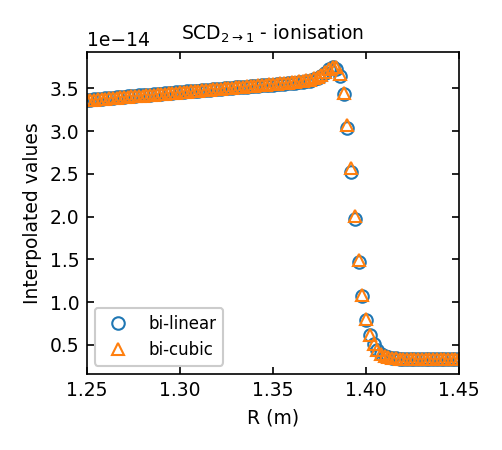

In [13]:
### recombination
fIoniseLinear = interp2d(Te0, ne0, dataIonise, kind='linear', bounds_error=True)
fIoniseCubic = interp2d(Te0, ne0, dataIonise, kind='cubic', bounds_error=True)

ioniseLinear = np.diag(fIoniseLinear(profileTemp, profileDensity))[::-1]
ioniseCubic = np.diag(fIoniseCubic(profileTemp, profileDensity))[::-1]


fig, ax = plt.subplots(1, 1, figsize=(3.35,3), dpi=150)
ax.plot(R, ioniseLinear, 'o', c='C0', mfc='None', label='bi-linear')
ax.plot(R, ioniseCubic, '^', c='C1', mfc='None', label='bi-cubic')
ax.set_title('SCD$_{2 \\rightarrow 1}$ - ionisation', fontsize=9)
ax.legend(fancybox=1, framealpha=1, fontsize=8)
ax.set_xlabel('R (m)', fontsize=9)
ax.set_ylabel('Interpolated values', fontsize=9)
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.yaxis.get_offset_text().set_size(9)
ax.set_xlim([R0, R1])
plt.tight_layout()

In [14]:
# neCarbon = np.array([
#     1.00E+11, 2.00E+11, 5.00E+11, 1.00E+12, 2.00E+12, 5.00E+12, 
#     1.00E+13, 2.00E+13, 5.00E+13, 1.00E+14, 2.00E+14, 5.00E+14, 
# ]) * 1e6 # ^m-3

# TeCarbon = np.array([
#     1.00E+00, 1.50E+00, 2.00E+00, 3.00E+00, 5.00E+00, 7.00E+00, 
#     1.00E+01, 1.50E+01, 2.00E+01, 3.00E+01, 5.00E+01, 6.89E+01, 
# ]) # eV

# excitCarbonstr = "1.24E-15 2.18E-13 2.63E-12 2.79E-11 1.57E-10 3.01E-10 4.61E-10 6.00E-10 6.59E-10 6.85E-10 6.47E-10 5.97E-10 1.24E-15 2.18E-13 2.62E-12 2.78E-11 1.56E-10 3.00E-10 4.58E-10 5.97E-10 6.56E-10 6.83E-10 6.45E-10 5.95E-10 1.24E-15 2.17E-13 2.62E-12 2.77E-11 1.55E-10 2.98E-10 4.56E-10 5.95E-10 6.53E-10 6.80E-10 6.43E-10 5.94E-10 1.24E-15 2.16E-13 2.60E-12 2.76E-11 1.55E-10 2.97E-10 4.54E-10 5.91E-10 6.50E-10 6.77E-10 6.40E-10 5.91E-10 1.23E-15 2.15E-13 2.58E-12 2.74E-11 1.53E-10 2.94E-10 4.49E-10 5.86E-10 6.44E-10 6.71E-10 6.36E-10 5.87E-10 1.21E-15 2.11E-13 2.53E-12 2.67E-11 1.49E-10 2.86E-10 4.37E-10 5.70E-10 6.27E-10 6.55E-10 6.22E-10 5.75E-10 1.17E-15 2.04E-13 2.44E-12 2.57E-11 1.43E-10 2.74E-10 4.19E-10 5.47E-10 6.02E-10 6.30E-10 6.00E-10 5.56E-10 1.11E-15 1.92E-13 2.28E-12 2.39E-11 1.32E-10 2.53E-10 3.87E-10 5.05E-10 5.58E-10 5.86E-10 5.61E-10 5.22E-10 9.65E-16 1.64E-13 1.94E-12 2.00E-11 1.09E-10 2.08E-10 3.17E-10 4.16E-10 4.60E-10 4.88E-10 4.73E-10 4.44E-10 8.10E-16 1.36E-13 1.58E-12 1.60E-11 8.64E-11 1.64E-10 2.49E-10 3.26E-10 3.63E-10 3.87E-10 3.81E-10 3.61E-10 6.42E-16 1.06E-13 1.21E-12 1.20E-11 6.31E-11 1.18E-10 1.79E-10 2.35E-10 2.62E-10 2.82E-10 2.82E-10 2.71E-10 4.51E-16 7.13E-14 7.89E-13 7.49E-12 3.79E-11 6.98E-11 1.05E-10 1.37E-10 1.54E-10 1.67E-10 1.70E-10 1.66E-10"
# excitCarbonlist = excitCarbonstr.split()
# excitCarbonarr = np.zeros(len(excitCarbonlist))
# for i in range(0, len(excitCarbonlist)):
#     excitCarbonarr[i] = float(excitCarbonlist[i]) / 1e6
# excitCarbon = np.reshape(excitCarbonarr, (len(neCarbon), len(TeCarbon)))

# np.savez(
#     '/home/sthoma/tokamak_inversion_routines/ADAS/EXCIT_pec93#c_pju#c1.npz', 
#     ne = neCarbon, 
#     Te = TeCarbon, 
#     data = excitCarbon, 
# )

In [15]:
# neCarbon = np.array([
#     1.00E+11, 2.00E+11, 5.00E+11, 1.00E+12, 2.00E+12, 5.00E+12, 
#     1.00E+13, 2.00E+13, 5.00E+13, 1.00E+14, 2.00E+14, 5.00E+14, 
# ]) * 1e6 # ^m-3

# TeCarbon = np.array([
#     1.00E+00, 1.50E+00, 2.00E+00, 3.00E+00, 5.00E+00, 7.00E+00, 
#     1.00E+01, 1.50E+01, 2.00E+01, 3.00E+01, 5.00E+01, 6.89E+01, 
# ]) # eV

# recomCarbonstr = "1.06E-13 9.67E-14 1.08E-13 1.43E-13 1.91E-13 2.00E-13 1.83E-13 1.43E-13 1.12E-13 7.53E-14 4.24E-14 2.87E-14 1.10E-13 9.81E-14 1.07E-13 1.36E-13 1.70E-13 1.74E-13 1.56E-13 1.21E-13 9.44E-14 6.32E-14 3.56E-14 2.42E-14 1.18E-13 1.00E-13 1.06E-13 1.26E-13 1.45E-13 1.42E-13 1.25E-13 9.47E-14 7.38E-14 4.93E-14 2.78E-14 1.90E-14 1.26E-13 1.03E-13 1.05E-13 1.19E-13 1.29E-13 1.23E-13 1.05E-13 7.89E-14 6.12E-14 4.08E-14 2.31E-14 1.59E-14 1.37E-13 1.06E-13 1.05E-13 1.13E-13 1.16E-13 1.07E-13 8.96E-14 6.63E-14 5.12E-14 3.40E-14 1.93E-14 1.33E-14 1.56E-13 1.11E-13 1.05E-13 1.06E-13 1.01E-13 9.02E-14 7.37E-14 5.36E-14 4.11E-14 2.73E-14 1.56E-14 1.08E-14 1.75E-13 1.16E-13 1.04E-13 1.01E-13 9.14E-14 7.96E-14 6.38E-14 4.59E-14 3.51E-14 2.32E-14 1.33E-14 9.26E-15 1.99E-13 1.20E-13 1.02E-13 9.34E-14 8.11E-14 6.91E-14 5.45E-14 3.88E-14 2.95E-14 1.96E-14 1.13E-14 7.88E-15 2.34E-13 1.23E-13 9.58E-14 7.97E-14 6.51E-14 5.40E-14 4.17E-14 2.92E-14 2.22E-14 1.47E-14 8.54E-15 6.02E-15 2.61E-13 1.22E-13 8.73E-14 6.68E-14 5.16E-14 4.18E-14 3.17E-14 2.20E-14 1.66E-14 1.10E-14 6.44E-15 4.57E-15 2.89E-13 1.20E-13 7.82E-14 5.39E-14 3.89E-14 3.07E-14 2.28E-14 1.56E-14 1.17E-14 7.71E-15 4.50E-15 3.21E-15 3.47E-13 1.24E-13 7.04E-14 4.09E-14 2.61E-14 1.96E-14 1.40E-14 9.26E-15 6.84E-15 4.44E-15 2.57E-15 1.83E-15"
# recomCarbonlist = recomCarbonstr.split()
# recomCarbonarr = np.zeros(len(recomCarbonlist))
# for i in range(0, len(recomCarbonlist)):
#     recomCarbonarr[i] = float(recomCarbonlist[i]) / 1e6
# recomCarbon = np.reshape(recomCarbonarr, (len(neCarbon), len(TeCarbon)))

# np.savez(
#     '/home/sthoma/tokamak_inversion_routines/ADAS/RECOM_pec93#c_pju#c1.npz', 
#     ne = neCarbon, 
#     Te = TeCarbon, 
#     data = recomCarbon, 
# )

In [16]:
excitCarbon = np.load('/home/sthoma/tokamak_inversion_routines/ADAS/EXCIT_pec93#c_pju#c1.npz')
neCarbon = excitCarbon['ne']
TeCarbon = excitCarbon['Te']
dataExciteCarbon = excitCarbon['data']
### units of [ph m^3 /s]
recomCarbon = np.load('/home/sthoma/tokamak_inversion_routines/ADAS/RECOM_pec93#c_pju#c1.npz')
dataRecombCarbon = recomCarbon['data']
### units of [ph m^3 /s]

################################
### no carbon IONIS, complex ###
################################

# ionis = np.load('/home/sthoma/tokamak_inversion_routines/ADAS/IONIS_scd12h.npz')
# dataIonise = ionis['data'][13:20,4:23]
# ### units of [m^3 /s]

In [17]:
# neCarbon2 = np.array([
#     1.28E+03, 1.28E+04, 1.28E+05, 1.28E+06, 1.28E+07, 1.28E+08, 3.84E+08, 1.28E+09,
#     3.84E+09, 1.28E+10, 3.84E+10, 1.28E+11, 3.84E+11, 1.28E+12, 3.84E+12, 1.28E+13,
#     3.84E+13, 1.28E+14, 3.84E+14, 1.28E+15, 3.84E+15, 1.28E+16, 3.84E+16, 1.28E+17,
# ]) * 1e6

# TeCarbon2 = np.array([
#     1.72E-01, 2.41E-01, 3.45E-01, 5.17E-01, 6.89E-01, 1.03E+00, 1.72E+00, 2.41E+00,
#     3.45E+00, 5.17E+00, 6.89E+00, 1.03E+01, 1.72E+01, 2.41E+01, 3.45E+01, 5.17E+01,
#     6.89E+01, 1.03E+02, 1.72E+02, 2.41E+02, 3.45E+02, 5.17E+02, 6.89E+02, 1.03E+03,
# ])

# excitCarbonstr2 = "1.00E-74 1.13E-37 6.41E-29 4.05E-22 1.00E-18 2.39E-15 1.14E-12 1.52E-11 1.02E-10 4.20E-10 8.19E-10 1.50E-09 2.24E-09 2.53E-09 2.66E-09 2.64E-09 2.55E-09 2.36E-09 2.09E-09 1.91E-09 1.72E-09 1.53E-09 1.41E-09 1.26E-09 1.00E-74 1.13E-37 6.41E-29 4.05E-22 1.00E-18 2.39E-15 1.14E-12 1.52E-11 1.02E-10 4.20E-10 8.19E-10 1.50E-09 2.24E-09 2.53E-09 2.66E-09 2.64E-09 2.55E-09 2.36E-09 2.09E-09 1.91E-09 1.72E-09 1.53E-09 1.41E-09 1.26E-09 1.00E-74 1.13E-37 6.41E-29 4.05E-22 1.00E-18 2.39E-15 1.14E-12 1.52E-11 1.02E-10 4.20E-10 8.19E-10 1.50E-09 2.24E-09 2.53E-09 2.66E-09 2.64E-09 2.55E-09 2.36E-09 2.09E-09 1.91E-09 1.72E-09 1.53E-09 1.41E-09 1.26E-09 1.00E-74 1.13E-37 6.41E-29 4.05E-22 1.00E-18 2.39E-15 1.14E-12 1.52E-11 1.02E-10 4.20E-10 8.19E-10 1.50E-09 2.24E-09 2.53E-09 2.66E-09 2.64E-09 2.55E-09 2.36E-09 2.09E-09 1.91E-09 1.72E-09 1.53E-09 1.41E-09 1.26E-09 1.00E-74 1.13E-37 6.42E-29 4.05E-22 1.00E-18 2.39E-15 1.14E-12 1.52E-11 1.02E-10 4.20E-10 8.18E-10 1.50E-09 2.23E-09 2.53E-09 2.66E-09 2.64E-09 2.55E-09 2.36E-09 2.09E-09 1.91E-09 1.72E-09 1.53E-09 1.41E-09 1.26E-09 1.00E-74 1.13E-37 6.45E-29 4.07E-22 1.01E-18 2.41E-15 1.14E-12 1.52E-11 1.02E-10 4.18E-10 8.13E-10 1.49E-09 2.22E-09 2.51E-09 2.65E-09 2.63E-09 2.55E-09 2.36E-09 2.09E-09 1.90E-09 1.72E-09 1.53E-09 1.41E-09 1.26E-09 1.00E-74 1.15E-37 6.53E-29 4.12E-22 1.02E-18 2.44E-15 1.15E-12 1.53E-11 1.01E-10 4.13E-10 8.01E-10 1.47E-09 2.19E-09 2.48E-09 2.63E-09 2.62E-09 2.53E-09 2.35E-09 2.08E-09 1.90E-09 1.72E-09 1.53E-09 1.41E-09 1.25E-09 1.00E-74 1.18E-37 6.69E-29 4.24E-22 1.05E-18 2.51E-15 1.17E-12 1.53E-11 9.99E-11 4.02E-10 7.74E-10 1.41E-09 2.11E-09 2.41E-09 2.57E-09 2.57E-09 2.50E-09 2.33E-09 2.07E-09 1.89E-09 1.71E-09 1.52E-09 1.40E-09 1.25E-09 1.00E-74 1.20E-37 6.87E-29 4.39E-22 1.09E-18 2.63E-15 1.20E-12 1.54E-11 9.82E-11 3.87E-10 7.36E-10 1.33E-09 2.00E-09 2.30E-09 2.49E-09 2.52E-09 2.46E-09 2.30E-09 2.05E-09 1.87E-09 1.70E-09 1.52E-09 1.40E-09 1.24E-09 1.00E-74 1.22E-37 7.01E-29 4.51E-22 1.13E-18 2.73E-15 1.24E-12 1.55E-11 9.67E-11 3.73E-10 7.03E-10 1.26E-09 1.89E-09 2.19E-09 2.42E-09 2.47E-09 2.42E-09 2.27E-09 2.03E-09 1.86E-09 1.69E-09 1.51E-09 1.39E-09 1.24E-09 1.00E-74 1.23E-37 7.06E-29 4.56E-22 1.15E-18 2.78E-15 1.25E-12 1.56E-11 9.59E-11 3.67E-10 6.87E-10 1.22E-09 1.84E-09 2.14E-09 2.38E-09 2.44E-09 2.40E-09 2.26E-09 2.03E-09 1.85E-09 1.68E-09 1.50E-09 1.39E-09 1.24E-09 3.00E-49 1.23E-37 7.07E-29 4.57E-22 1.15E-18 2.80E-15 1.26E-12 1.55E-11 9.53E-11 3.63E-10 6.79E-10 1.21E-09 1.81E-09 2.11E-09 2.36E-09 2.43E-09 2.39E-09 2.25E-09 2.02E-09 1.85E-09 1.68E-09 1.50E-09 1.38E-09 1.23E-09 2.00E-49 1.22E-37 7.02E-29 4.55E-22 1.15E-18 2.78E-15 1.25E-12 1.54E-11 9.42E-11 3.59E-10 6.70E-10 1.19E-09 1.79E-09 2.09E-09 2.34E-09 2.41E-09 2.37E-09 2.24E-09 2.01E-09 1.84E-09 1.67E-09 1.49E-09 1.38E-09 1.23E-09 2.40E-49 1.19E-37 6.85E-29 4.45E-22 1.12E-18 2.72E-15 1.21E-12 1.49E-11 9.10E-11 3.46E-10 6.45E-10 1.15E-09 1.73E-09 2.02E-09 2.27E-09 2.34E-09 2.31E-09 2.18E-09 1.96E-09 1.80E-09 1.64E-09 1.47E-09 1.36E-09 1.21E-09 2.20E-49 1.10E-37 6.43E-29 4.18E-22 1.06E-18 2.54E-15 1.12E-12 1.37E-11 8.29E-11 3.14E-10 5.85E-10 1.04E-09 1.57E-09 1.84E-09 2.08E-09 2.16E-09 2.14E-09 2.04E-09 1.85E-09 1.71E-09 1.56E-09 1.40E-09 1.30E-09 1.17E-09 1.83E-49 9.26E-38 5.45E-29 3.56E-22 8.92E-19 2.11E-15 9.05E-13 1.08E-11 6.43E-11 2.40E-10 4.45E-10 7.89E-10 1.20E-09 1.42E-09 1.63E-09 1.71E-09 1.71E-09 1.66E-09 1.54E-09 1.44E-09 1.33E-09 1.21E-09 1.14E-09 1.03E-09 1.42E-49 7.25E-38 4.27E-29 2.76E-22 6.82E-19 1.56E-15 6.31E-13 7.27E-12 4.18E-11 1.52E-10 2.78E-10 4.89E-10 7.49E-10 8.95E-10 1.04E-09 1.11E-09 1.12E-09 1.11E-09 1.06E-09 1.01E-09 9.49E-10 8.85E-10 8.39E-10 7.79E-10 1.11E-49 5.63E-38 3.27E-29 2.06E-22 4.94E-19 1.06E-15 3.83E-13 4.11E-12 2.22E-11 7.65E-11 1.37E-10 2.38E-10 3.64E-10 4.37E-10 5.10E-10 5.48E-10 5.60E-10 5.61E-10 5.47E-10 5.28E-10 5.07E-10 4.83E-10 4.65E-10 4.41E-10 9.02E-50 4.58E-38 2.66E-29 1.66E-22 3.90E-19 7.73E-16 2.38E-13 2.33E-12 1.17E-11 3.81E-11 6.67E-11 1.14E-10 1.74E-10 2.09E-10 2.43E-10 2.62E-10 2.69E-10 2.71E-10 2.66E-10 2.59E-10 2.50E-10 2.40E-10 2.33E-10 2.23E-10 6.24E-50 3.26E-38 1.94E-29 1.24E-22 2.93E-19 5.44E-16 1.40E-13 1.22E-12 5.59E-12 1.70E-11 2.88E-11 4.84E-11 7.37E-11 8.82E-11 1.02E-10 1.10E-10 1.13E-10 1.14E-10 1.14E-10 1.11E-10 1.09E-10 1.06E-10 1.03E-10 1.00E-10 3.42E-50 1.86E-38 1.15E-29 7.69E-23 1.88E-19 3.57E-16 8.02E-14 6.30E-13 2.63E-12 7.40E-12 1.22E-11 2.01E-11 3.02E-11 3.59E-11 4.09E-11 4.42E-11 4.56E-11 4.67E-11 4.70E-11 4.68E-11 4.64E-11 4.58E-11 4.53E-11 4.46E-11 1.34E-50 7.45E-39 4.77E-30 3.33E-23 8.51E-20 1.77E-16 3.66E-14 2.63E-13 1.02E-12 2.69E-12 4.30E-12 6.91E-12 1.01E-11 1.18E-11 1.33E-11 1.43E-11 1.48E-11 1.52E-11 1.55E-11 1.56E-11 1.57E-11 1.57E-11 1.58E-11 1.58E-11 4.88E-51 2.76E-39 1.79E-30 1.27E-23 3.34E-20 7.41E-17 1.51E-14 1.06E-13 3.95E-13 1.00E-12 1.56E-12 2.43E-12 3.42E-12 3.91E-12 4.31E-12 4.58E-12 4.71E-12 4.85E-12 4.97E-12 5.04E-12 5.11E-12 5.19E-12 5.25E-12 5.34E-12 1.51E-51 8.60E-40 5.62E-31 4.03E-24 1.07E-20 2.46E-17 5.07E-15 3.54E-14 1.30E-13 3.20E-13 4.87E-13 7.28E-13 9.72E-13 1.08E-12 1.16E-12 1.21E-12 1.23E-12 1.26E-12 1.29E-12 1.31E-12 1.33E-12 1.36E-12 1.38E-12 1.41E-12"
# excitCarbonlist2 = excitCarbonstr2.split()
# excitCarbonarr2 = np.zeros(len(excitCarbonlist2))
# for i in range(0, len(excitCarbonlist2)):
#     excitCarbonarr2[i] = float(excitCarbonlist2[i]) / 1e6
# excitCarbon2 = np.reshape(excitCarbonarr2, (len(neCarbon2), len(TeCarbon2)))

# np.savez(
#     '/home/sthoma/tokamak_inversion_routines/ADAS/EXCIT_pec96#c_vsr#c1.npz', 
#     ne = neCarbon2, 
#     Te = TeCarbon2, 
#     data = excitCarbon2, 
# )

In [18]:
# neCarbon2 = np.array([
#     1.28E+03, 1.28E+04, 1.28E+05, 1.28E+06, 1.28E+07, 1.28E+08, 3.84E+08, 1.28E+09,
#     3.84E+09, 1.28E+10, 3.84E+10, 1.28E+11, 3.84E+11, 1.28E+12, 3.84E+12, 1.28E+13,
#     3.84E+13, 1.28E+14, 3.84E+14, 1.28E+15, 3.84E+15, 1.28E+16, 3.84E+16, 1.28E+17,
# ]) * 1e6

# TeCarbon2 = np.array([
#     1.72E-01, 2.41E-01, 3.45E-01, 5.17E-01, 6.89E-01, 1.03E+00, 1.72E+00, 2.41E+00,
#     3.45E+00, 5.17E+00, 6.89E+00, 1.03E+01, 1.72E+01, 2.41E+01, 3.45E+01, 5.17E+01,
#     6.89E+01, 1.03E+02, 1.72E+02, 2.41E+02, 3.45E+02, 5.17E+02, 6.89E+02, 1.03E+03,
# ])

# recomCarbonstr2 = "3.89E-13 3.54E-13 3.21E-13 2.87E-13 2.65E-13 2.46E-13 3.40E-13 6.57E-13 1.33E-12 2.17E-12 2.52E-12 2.48E-12 1.87E-12 1.40E-12 9.63E-13 5.98E-13 4.16E-13 2.44E-13 1.21E-13 7.52E-14 4.52E-14 2.53E-14 1.67E-14 9.25E-15 3.90E-13 3.55E-13 3.22E-13 2.87E-13 2.65E-13 2.46E-13 3.31E-13 6.13E-13 1.21E-12 1.95E-12 2.25E-12 2.21E-12 1.66E-12 1.24E-12 8.58E-13 5.34E-13 3.72E-13 2.18E-13 1.09E-13 6.77E-14 4.08E-14 2.28E-14 1.51E-14 8.41E-15 3.94E-13 3.58E-13 3.24E-13 2.89E-13 2.67E-13 2.47E-13 3.21E-13 5.62E-13 1.06E-12 1.68E-12 1.92E-12 1.89E-12 1.42E-12 1.06E-12 7.36E-13 4.59E-13 3.21E-13 1.89E-13 9.44E-14 5.91E-14 3.58E-14 2.01E-14 1.33E-14 7.45E-15 4.03E-13 3.65E-13 3.30E-13 2.93E-13 2.69E-13 2.48E-13 3.11E-13 5.13E-13 9.21E-13 1.42E-12 1.61E-12 1.56E-12 1.18E-12 8.79E-13 6.09E-13 3.81E-13 2.66E-13 1.57E-13 7.89E-14 4.95E-14 3.01E-14 1.70E-14 1.13E-14 6.34E-15 4.24E-13 3.82E-13 3.41E-13 3.01E-13 2.75E-13 2.50E-13 3.03E-13 4.66E-13 7.87E-13 1.17E-12 1.31E-12 1.26E-12 9.46E-13 7.08E-13 4.91E-13 3.08E-13 2.16E-13 1.28E-13 6.46E-14 4.07E-14 2.48E-14 1.40E-14 9.35E-15 5.27E-15 4.65E-13 4.13E-13 3.63E-13 3.15E-13 2.84E-13 2.55E-13 2.96E-13 4.23E-13 6.63E-13 9.34E-13 1.03E-12 9.76E-13 7.25E-13 5.42E-13 3.77E-13 2.37E-13 1.67E-13 9.94E-14 5.05E-14 3.20E-14 1.96E-14 1.12E-14 7.47E-15 4.24E-15 4.93E-13 4.33E-13 3.78E-13 3.24E-13 2.90E-13 2.57E-13 2.94E-13 4.08E-13 6.18E-13 8.47E-13 9.22E-13 8.67E-13 6.40E-13 4.77E-13 3.31E-13 2.08E-13 1.46E-13 8.72E-14 4.44E-14 2.81E-14 1.72E-14 9.85E-15 6.61E-15 3.77E-15 5.42E-13 4.69E-13 4.03E-13 3.40E-13 3.01E-13 2.62E-13 2.92E-13 3.93E-13 5.73E-13 7.64E-13 8.22E-13 7.65E-13 5.62E-13 4.18E-13 2.90E-13 1.82E-13 1.28E-13 7.65E-14 3.89E-14 2.47E-14 1.51E-14 8.64E-15 5.80E-15 3.31E-15 6.13E-13 5.21E-13 4.39E-13 3.61E-13 3.15E-13 2.69E-13 2.92E-13 3.80E-13 5.33E-13 6.88E-13 7.30E-13 6.73E-13 4.91E-13 3.65E-13 2.54E-13 1.60E-13 1.13E-13 6.75E-14 3.45E-14 2.19E-14 1.35E-14 7.73E-15 5.20E-15 2.97E-15 7.33E-13 6.07E-13 4.96E-13 3.95E-13 3.36E-13 2.78E-13 2.92E-13 3.67E-13 4.91E-13 6.09E-13 6.35E-13 5.76E-13 4.17E-13 3.10E-13 2.15E-13 1.36E-13 9.60E-14 5.78E-14 2.98E-14 1.90E-14 1.17E-14 6.76E-15 4.56E-15 2.62E-15 9.03E-13 7.24E-13 5.73E-13 4.39E-13 3.63E-13 2.90E-13 2.94E-13 3.56E-13 4.57E-13 5.44E-13 5.56E-13 4.97E-13 3.56E-13 2.64E-13 1.83E-13 1.16E-13 8.20E-14 4.96E-14 2.57E-14 1.64E-14 1.02E-14 5.90E-15 4.00E-15 2.31E-15 1.21E-12 9.28E-13 7.01E-13 5.09E-13 4.06E-13 3.08E-13 2.97E-13 3.46E-13 4.23E-13 4.81E-13 4.80E-13 4.20E-13 2.97E-13 2.19E-13 1.52E-13 9.65E-14 6.86E-14 4.17E-14 2.17E-14 1.40E-14 8.68E-15 5.05E-15 3.44E-15 2.00E-15 1.73E-12 1.26E-12 8.95E-13 6.10E-13 4.64E-13 3.32E-13 3.01E-13 3.37E-13 3.92E-13 4.25E-13 4.14E-13 3.54E-13 2.47E-13 1.82E-13 1.26E-13 8.04E-14 5.74E-14 3.51E-14 1.85E-14 1.19E-14 7.46E-15 4.37E-15 2.98E-15 1.74E-15 2.84E-12 1.91E-12 1.26E-12 7.79E-13 5.55E-13 3.63E-13 3.03E-13 3.21E-13 3.54E-13 3.62E-13 3.41E-13 2.83E-13 1.94E-13 1.42E-13 9.90E-14 6.34E-14 4.56E-14 2.82E-14 1.50E-14 9.79E-15 6.17E-15 3.65E-15 2.51E-15 1.48E-15 4.76E-12 2.94E-12 1.76E-12 9.84E-13 6.52E-13 3.86E-13 2.92E-13 2.92E-13 3.04E-13 2.94E-13 2.68E-13 2.16E-13 1.45E-13 1.07E-13 7.45E-14 4.82E-14 3.49E-14 2.19E-14 1.19E-14 7.83E-15 5.00E-15 2.99E-15 2.08E-15 1.24E-15 8.19E-12 4.53E-12 2.42E-12 1.19E-12 7.17E-13 3.73E-13 2.45E-13 2.27E-13 2.21E-13 2.01E-13 1.77E-13 1.37E-13 9.11E-14 6.72E-14 4.75E-14 3.12E-14 2.29E-14 1.47E-14 8.26E-15 5.55E-15 3.61E-15 2.20E-15 1.55E-15 9.48E-16 1.20E-11 5.97E-12 2.86E-12 1.24E-12 6.84E-13 3.14E-13 1.76E-13 1.50E-13 1.35E-13 1.16E-13 9.90E-14 7.48E-14 4.91E-14 3.64E-14 2.61E-14 1.74E-14 1.30E-14 8.58E-15 4.98E-15 3.43E-15 2.28E-15 1.43E-15 1.03E-15 6.46E-16 1.89E-11 8.43E-12 3.59E-12 1.36E-12 6.83E-13 2.71E-13 1.19E-13 8.69E-14 7.01E-14 5.50E-14 4.50E-14 3.28E-14 2.11E-14 1.56E-14 1.12E-14 7.61E-15 5.74E-15 3.87E-15 2.32E-15 1.63E-15 1.11E-15 7.21E-16 5.30E-16 3.43E-16 4.04E-11 1.68E-11 6.62E-12 2.30E-12 1.08E-12 3.79E-13 1.14E-13 6.35E-14 4.16E-14 2.83E-14 2.18E-14 1.50E-14 9.26E-15 6.76E-15 4.83E-15 3.26E-15 2.46E-15 1.67E-15 1.02E-15 7.25E-16 5.02E-16 3.32E-16 2.48E-16 1.64E-16 9.25E-11 3.97E-11 1.62E-11 5.84E-12 2.83E-12 9.62E-13 1.85E-13 6.94E-14 3.13E-14 1.61E-14 1.10E-14 6.77E-15 3.87E-15 2.73E-15 1.90E-15 1.26E-15 9.42E-16 6.34E-16 3.85E-16 2.75E-16 1.92E-16 1.28E-16 9.67E-17 6.52E-17 1.30E-10 6.25E-11 2.87E-11 1.18E-11 6.32E-12 2.31E-12 3.36E-13 9.48E-14 3.11E-14 1.18E-14 6.88E-15 3.64E-15 1.84E-15 1.23E-15 8.20E-16 5.26E-16 3.87E-16 2.56E-16 1.53E-16 1.09E-16 7.58E-17 5.06E-17 3.83E-17 2.60E-17 1.23E-10 6.77E-11 3.59E-11 1.75E-11 1.05E-11 4.27E-12 5.21E-13 1.22E-13 3.31E-14 1.01E-14 5.09E-15 2.27E-15 9.72E-16 5.96E-16 3.69E-16 2.21E-16 1.57E-16 9.86E-17 5.65E-17 3.93E-17 2.69E-17 1.78E-17 1.33E-17 8.97E-18 1.08E-10 6.44E-11 3.71E-11 1.99E-11 1.27E-11 5.54E-12 6.24E-13 1.36E-13 3.43E-14 9.58E-15 4.51E-15 1.82E-15 6.92E-16 3.94E-16 2.26E-16 1.26E-16 8.46E-17 4.98E-17 2.65E-17 1.77E-17 1.16E-17 7.37E-18 5.39E-18 3.52E-18 1.01E-10 6.21E-11 3.72E-11 2.08E-11 1.37E-11 6.17E-12 6.72E-13 1.42E-13 3.48E-14 9.38E-15 4.28E-15 1.64E-15 5.85E-16 3.18E-16 1.73E-16 9.07E-17 5.84E-17 3.21E-17 1.56E-17 9.86E-18 6.13E-18 3.63E-18 2.53E-18 1.55E-18"
# recomCarbonlist2 = recomCarbonstr2.split()
# recomCarbonarr2 = np.zeros(len(recomCarbonlist2))
# for i in range(0, len(recomCarbonlist2)):
#     recomCarbonarr2[i] = float(recomCarbonlist2[i]) / 1e6
# recomCarbon2 = np.reshape(recomCarbonarr2, (len(neCarbon2), len(TeCarbon2)))

# np.savez(
#     '/home/sthoma/tokamak_inversion_routines/ADAS/RECOM_pec96#c_vsr#c1.npz', 
#     ne = neCarbon2, 
#     Te = TeCarbon2, 
#     data = recomCarbon2, 
# )

In [19]:
excitCarbon2 = np.load('/home/sthoma/tokamak_inversion_routines/ADAS/EXCIT_pec96#c_vsr#c1.npz')
neCarbon2 = excitCarbon2['ne'][10:20]
TeCarbon2 = excitCarbon2['Te'][5:]
dataExciteCarbon2 = excitCarbon2['data'][10:20,5:]
### units of [ph m^3 /s]
recomCarbon2 = np.load('/home/sthoma/tokamak_inversion_routines/ADAS/RECOM_pec96#c_vsr#c1.npz')
dataRecombCarbon2 = recomCarbon2['data'][10:20,5:]
### units of [ph m^3 /s]

################################
### no carbon IONIS, complex ###
################################

# ionis = np.load('/home/sthoma/tokamak_inversion_routines/ADAS/IONIS_scd12h.npz')
# dataIonise = ionis['data'][13:20,4:23]
# ### units of [m^3 /s]

In [20]:
# neCarbon3 = np.array([
#     1.28E+03, 1.28E+04, 1.28E+05, 1.28E+06, 1.28E+07, 1.28E+08, 3.84E+08, 1.28E+09,
#     3.84E+09, 1.28E+10, 3.84E+10, 1.28E+11, 3.84E+11, 1.28E+12, 3.84E+12, 1.28E+13,
#     3.84E+13, 1.28E+14, 3.84E+14, 1.28E+15, 3.84E+15, 1.28E+16, 3.84E+16, 1.28E+17,
# ]) * 1e6

# TeCarbon3 = np.array([
#     1.72E-01, 2.41E-01, 3.45E-01, 5.17E-01, 6.89E-01, 1.03E+00, 1.72E+00, 2.41E+00,
#     3.45E+00, 5.17E+00, 6.89E+00, 1.03E+01, 1.72E+01, 2.41E+01, 3.45E+01, 5.17E+01,
#     6.89E+01, 1.03E+02, 1.72E+02, 2.41E+02, 3.45E+02, 5.17E+02, 6.89E+02, 1.03E+03,
# ])

# excitCarbonstr3 = "1.00E-74 1.13E-37 6.41E-29 4.05E-22 1.00E-18 2.39E-15 1.14E-12 1.52E-11 1.02E-10 4.20E-10 8.19E-10 1.50E-09 2.24E-09 2.53E-09 2.66E-09 2.64E-09 2.55E-09 2.36E-09 2.09E-09 1.91E-09 1.72E-09 1.53E-09 1.41E-09 1.26E-09 1.00E-74 1.13E-37 6.41E-29 4.05E-22 1.00E-18 2.39E-15 1.14E-12 1.52E-11 1.02E-10 4.20E-10 8.19E-10 1.50E-09 2.24E-09 2.53E-09 2.66E-09 2.64E-09 2.55E-09 2.36E-09 2.09E-09 1.91E-09 1.72E-09 1.53E-09 1.41E-09 1.26E-09 1.00E-74 1.13E-37 6.41E-29 4.05E-22 1.00E-18 2.39E-15 1.14E-12 1.52E-11 1.02E-10 4.20E-10 8.19E-10 1.50E-09 2.24E-09 2.53E-09 2.66E-09 2.64E-09 2.55E-09 2.36E-09 2.09E-09 1.91E-09 1.72E-09 1.53E-09 1.41E-09 1.26E-09 1.00E-74 1.13E-37 6.41E-29 4.05E-22 1.00E-18 2.39E-15 1.14E-12 1.52E-11 1.02E-10 4.20E-10 8.19E-10 1.50E-09 2.24E-09 2.53E-09 2.66E-09 2.64E-09 2.55E-09 2.36E-09 2.09E-09 1.91E-09 1.72E-09 1.53E-09 1.41E-09 1.26E-09 1.00E-74 1.13E-37 6.41E-29 4.05E-22 1.00E-18 2.39E-15 1.14E-12 1.52E-11 1.02E-10 4.20E-10 8.19E-10 1.50E-09 2.24E-09 2.53E-09 2.66E-09 2.64E-09 2.55E-09 2.36E-09 2.09E-09 1.91E-09 1.72E-09 1.53E-09 1.41E-09 1.26E-09 1.00E-74 1.13E-37 6.41E-29 4.05E-22 1.00E-18 2.39E-15 1.14E-12 1.52E-11 1.02E-10 4.20E-10 8.19E-10 1.50E-09 2.24E-09 2.53E-09 2.66E-09 2.64E-09 2.55E-09 2.36E-09 2.09E-09 1.91E-09 1.72E-09 1.53E-09 1.41E-09 1.26E-09 1.00E-74 1.13E-37 6.41E-29 4.05E-22 1.00E-18 2.39E-15 1.14E-12 1.52E-11 1.02E-10 4.20E-10 8.19E-10 1.50E-09 2.24E-09 2.53E-09 2.66E-09 2.64E-09 2.55E-09 2.36E-09 2.09E-09 1.91E-09 1.72E-09 1.53E-09 1.41E-09 1.26E-09 1.00E-74 1.13E-37 6.41E-29 4.05E-22 1.00E-18 2.39E-15 1.14E-12 1.52E-11 1.02E-10 4.20E-10 8.19E-10 1.50E-09 2.24E-09 2.53E-09 2.66E-09 2.64E-09 2.55E-09 2.36E-09 2.09E-09 1.91E-09 1.72E-09 1.53E-09 1.41E-09 1.26E-09 1.00E-74 1.13E-37 6.41E-29 4.05E-22 1.00E-18 2.39E-15 1.14E-12 1.52E-11 1.02E-10 4.20E-10 8.19E-10 1.50E-09 2.24E-09 2.53E-09 2.66E-09 2.64E-09 2.55E-09 2.36E-09 2.09E-09 1.91E-09 1.72E-09 1.53E-09 1.41E-09 1.26E-09 1.00E-74 1.13E-37 6.41E-29 4.04E-22 1.00E-18 2.39E-15 1.13E-12 1.52E-11 1.02E-10 4.20E-10 8.19E-10 1.50E-09 2.23E-09 2.53E-09 2.66E-09 2.64E-09 2.55E-09 2.36E-09 2.09E-09 1.91E-09 1.72E-09 1.53E-09 1.41E-09 1.26E-09 1.00E-74 1.12E-37 6.40E-29 4.04E-22 9.99E-19 2.39E-15 1.13E-12 1.52E-11 1.02E-10 4.20E-10 8.18E-10 1.50E-09 2.23E-09 2.52E-09 2.66E-09 2.64E-09 2.55E-09 2.36E-09 2.09E-09 1.91E-09 1.72E-09 1.53E-09 1.41E-09 1.26E-09 3.00E-49 1.12E-37 6.39E-29 4.03E-22 9.97E-19 2.38E-15 1.13E-12 1.51E-11 1.01E-10 4.18E-10 8.15E-10 1.49E-09 2.22E-09 2.52E-09 2.65E-09 2.63E-09 2.54E-09 2.36E-09 2.08E-09 1.90E-09 1.72E-09 1.53E-09 1.41E-09 1.25E-09 2.00E-49 1.11E-37 6.34E-29 4.00E-22 9.90E-19 2.37E-15 1.12E-12 1.50E-11 1.00E-10 4.14E-10 8.07E-10 1.48E-09 2.20E-09 2.49E-09 2.63E-09 2.61E-09 2.53E-09 2.34E-09 2.07E-09 1.89E-09 1.71E-09 1.52E-09 1.40E-09 1.25E-09 2.10E-49 1.08E-37 6.17E-29 3.91E-22 9.66E-19 2.31E-15 1.09E-12 1.45E-11 9.69E-11 4.00E-10 7.78E-10 1.43E-09 2.13E-09 2.42E-09 2.55E-09 2.54E-09 2.46E-09 2.29E-09 2.03E-09 1.86E-09 1.68E-09 1.50E-09 1.38E-09 1.23E-09 2.00E-49 1.00E-37 5.77E-29 3.67E-22 9.07E-19 2.16E-15 1.01E-12 1.33E-11 8.85E-11 3.63E-10 7.07E-10 1.30E-09 1.94E-09 2.21E-09 2.35E-09 2.35E-09 2.29E-09 2.14E-09 1.91E-09 1.76E-09 1.60E-09 1.44E-09 1.33E-09 1.19E-09 1.62E-49 8.26E-38 4.85E-29 3.10E-22 7.65E-19 1.79E-15 8.14E-13 1.06E-11 6.89E-11 2.79E-10 5.41E-10 9.92E-10 1.49E-09 1.72E-09 1.84E-09 1.87E-09 1.84E-09 1.74E-09 1.59E-09 1.49E-09 1.37E-09 1.24E-09 1.16E-09 1.05E-09 1.23E-49 6.33E-38 3.73E-29 2.38E-22 5.80E-19 1.32E-15 5.70E-13 7.15E-12 4.50E-11 1.78E-10 3.41E-10 6.21E-10 9.38E-10 1.09E-09 1.18E-09 1.22E-09 1.21E-09 1.17E-09 1.10E-09 1.04E-09 9.81E-10 9.10E-10 8.62E-10 7.98E-10 9.39E-50 4.78E-38 2.79E-29 1.75E-22 4.17E-19 8.96E-16 3.47E-13 4.07E-12 2.42E-11 9.11E-11 1.71E-10 3.06E-10 4.61E-10 5.36E-10 5.87E-10 6.09E-10 6.10E-10 6.00E-10 5.76E-10 5.55E-10 5.30E-10 5.02E-10 4.82E-10 4.57E-10 7.51E-50 3.84E-38 2.24E-29 1.39E-22 3.27E-19 6.53E-16 2.18E-13 2.33E-12 1.30E-11 4.63E-11 8.49E-11 1.50E-10 2.24E-10 2.59E-10 2.84E-10 2.97E-10 2.98E-10 2.95E-10 2.86E-10 2.77E-10 2.66E-10 2.54E-10 2.46E-10 2.35E-10 5.16E-50 2.71E-38 1.62E-29 1.04E-22 2.44E-19 4.60E-16 1.28E-13 1.24E-12 6.34E-12 2.14E-11 3.82E-11 6.61E-11 9.79E-11 1.13E-10 1.24E-10 1.30E-10 1.32E-10 1.31E-10 1.28E-10 1.25E-10 1.22E-10 1.18E-10 1.15E-10 1.11E-10 2.82E-50 1.54E-38 9.57E-30 6.40E-23 1.56E-19 3.01E-16 7.34E-14 6.42E-13 3.05E-12 9.79E-12 1.72E-11 2.94E-11 4.33E-11 5.01E-11 5.50E-11 5.81E-11 5.91E-11 5.93E-11 5.86E-11 5.79E-11 5.71E-11 5.60E-11 5.53E-11 5.42E-11 1.10E-50 6.17E-39 3.97E-30 2.77E-23 7.08E-20 1.48E-16 3.31E-14 2.67E-13 1.21E-12 3.77E-12 6.55E-12 1.11E-11 1.64E-11 1.89E-11 2.08E-11 2.21E-11 2.25E-11 2.28E-11 2.28E-11 2.28E-11 2.28E-11 2.28E-11 2.28E-11 2.28E-11 4.01E-51 2.28E-39 1.49E-30 1.06E-23 2.78E-20 6.20E-17 1.35E-14 1.06E-13 4.73E-13 1.46E-12 2.53E-12 4.26E-12 6.21E-12 7.16E-12 7.87E-12 8.37E-12 8.59E-12 8.73E-12 8.83E-12 8.91E-12 9.01E-12 9.15E-12 9.25E-12 9.41E-12 1.25E-51 7.12E-40 4.67E-31 3.35E-24 8.89E-21 2.05E-17 4.49E-15 3.52E-14 1.57E-13 4.81E-13 8.23E-13 1.36E-12 1.96E-12 2.24E-12 2.46E-12 2.61E-12 2.68E-12 2.74E-12 2.79E-12 2.84E-12 2.90E-12 2.98E-12 3.04E-12 3.14E-12"
# excitCarbonlist3 = excitCarbonstr3.split()
# excitCarbonarr3 = np.zeros(len(excitCarbonlist3))
# for i in range(0, len(excitCarbonlist3)):
#     excitCarbonarr3[i] = float(excitCarbonlist3[i]) / 1e6
# excitCarbon3 = np.reshape(excitCarbonarr3, (len(neCarbon3), len(TeCarbon3)))

# np.savez(
#     '/home/sthoma/tokamak_inversion_routines/ADAS/EXCIT_pec96#c_vsu#c1.npz', 
#     ne = neCarbon3, 
#     Te = TeCarbon3, 
#     data = excitCarbon3, 
# )

In [21]:
# neCarbon3 = np.array([
#     1.28E+03, 1.28E+04, 1.28E+05, 1.28E+06, 1.28E+07, 1.28E+08, 3.84E+08, 1.28E+09,
#     3.84E+09, 1.28E+10, 3.84E+10, 1.28E+11, 3.84E+11, 1.28E+12, 3.84E+12, 1.28E+13,
#     3.84E+13, 1.28E+14, 3.84E+14, 1.28E+15, 3.84E+15, 1.28E+16, 3.84E+16, 1.28E+17,
# ]) * 1e6

# TeCarbon3 = np.array([
#     1.72E-01, 2.41E-01, 3.45E-01, 5.17E-01, 6.89E-01, 1.03E+00, 1.72E+00, 2.41E+00,
#     3.45E+00, 5.17E+00, 6.89E+00, 1.03E+01, 1.72E+01, 2.41E+01, 3.45E+01, 5.17E+01,
#     6.89E+01, 1.03E+02, 1.72E+02, 2.41E+02, 3.45E+02, 5.17E+02, 6.89E+02, 1.03E+03,
# ])

# excitCarbonstr3 = "3.89E-13 3.54E-13 3.21E-13 2.87E-13 2.65E-13 2.46E-13 3.40E-13 6.57E-13 1.33E-12 2.17E-12 2.52E-12 2.48E-12 1.87E-12 1.40E-12 9.63E-13 5.98E-13 4.16E-13 2.44E-13 1.21E-13 7.52E-14 4.52E-14 2.53E-14 1.67E-14 9.25E-15 3.90E-13 3.55E-13 3.22E-13 2.87E-13 2.65E-13 2.46E-13 3.31E-13 6.13E-13 1.21E-12 1.95E-12 2.25E-12 2.21E-12 1.66E-12 1.24E-12 8.58E-13 5.34E-13 3.72E-13 2.18E-13 1.09E-13 6.77E-14 4.08E-14 2.28E-14 1.51E-14 8.41E-15 3.94E-13 3.58E-13 3.24E-13 2.89E-13 2.67E-13 2.47E-13 3.21E-13 5.62E-13 1.06E-12 1.68E-12 1.92E-12 1.89E-12 1.42E-12 1.06E-12 7.36E-13 4.59E-13 3.21E-13 1.89E-13 9.44E-14 5.91E-14 3.58E-14 2.01E-14 1.33E-14 7.45E-15 4.03E-13 3.65E-13 3.30E-13 2.93E-13 2.69E-13 2.48E-13 3.11E-13 5.13E-13 9.21E-13 1.42E-12 1.61E-12 1.56E-12 1.18E-12 8.79E-13 6.09E-13 3.81E-13 2.66E-13 1.57E-13 7.89E-14 4.95E-14 3.01E-14 1.70E-14 1.13E-14 6.34E-15 4.24E-13 3.82E-13 3.41E-13 3.01E-13 2.75E-13 2.50E-13 3.03E-13 4.66E-13 7.87E-13 1.17E-12 1.31E-12 1.26E-12 9.46E-13 7.08E-13 4.91E-13 3.08E-13 2.16E-13 1.28E-13 6.46E-14 4.07E-14 2.48E-14 1.40E-14 9.35E-15 5.27E-15 4.65E-13 4.13E-13 3.63E-13 3.15E-13 2.84E-13 2.55E-13 2.96E-13 4.23E-13 6.63E-13 9.34E-13 1.03E-12 9.76E-13 7.25E-13 5.42E-13 3.77E-13 2.37E-13 1.67E-13 9.94E-14 5.05E-14 3.20E-14 1.96E-14 1.12E-14 7.47E-15 4.24E-15 4.93E-13 4.33E-13 3.78E-13 3.24E-13 2.90E-13 2.57E-13 2.94E-13 4.08E-13 6.18E-13 8.47E-13 9.22E-13 8.67E-13 6.40E-13 4.77E-13 3.31E-13 2.08E-13 1.46E-13 8.72E-14 4.44E-14 2.81E-14 1.72E-14 9.85E-15 6.61E-15 3.77E-15 5.42E-13 4.69E-13 4.03E-13 3.40E-13 3.01E-13 2.62E-13 2.92E-13 3.93E-13 5.73E-13 7.64E-13 8.22E-13 7.65E-13 5.62E-13 4.18E-13 2.90E-13 1.82E-13 1.28E-13 7.65E-14 3.89E-14 2.47E-14 1.51E-14 8.64E-15 5.80E-15 3.31E-15 6.13E-13 5.21E-13 4.39E-13 3.61E-13 3.15E-13 2.69E-13 2.92E-13 3.80E-13 5.33E-13 6.88E-13 7.30E-13 6.73E-13 4.91E-13 3.65E-13 2.54E-13 1.60E-13 1.13E-13 6.75E-14 3.45E-14 2.19E-14 1.35E-14 7.73E-15 5.20E-15 2.97E-15 7.33E-13 6.07E-13 4.96E-13 3.95E-13 3.36E-13 2.78E-13 2.92E-13 3.67E-13 4.91E-13 6.09E-13 6.35E-13 5.76E-13 4.17E-13 3.10E-13 2.15E-13 1.36E-13 9.60E-14 5.78E-14 2.98E-14 1.90E-14 1.17E-14 6.76E-15 4.56E-15 2.62E-15 9.03E-13 7.24E-13 5.73E-13 4.39E-13 3.63E-13 2.90E-13 2.94E-13 3.56E-13 4.57E-13 5.44E-13 5.56E-13 4.97E-13 3.56E-13 2.64E-13 1.83E-13 1.16E-13 8.20E-14 4.96E-14 2.57E-14 1.64E-14 1.02E-14 5.90E-15 4.00E-15 2.31E-15 1.21E-12 9.28E-13 7.01E-13 5.09E-13 4.06E-13 3.08E-13 2.97E-13 3.46E-13 4.23E-13 4.81E-13 4.80E-13 4.20E-13 2.97E-13 2.19E-13 1.52E-13 9.65E-14 6.86E-14 4.17E-14 2.17E-14 1.40E-14 8.68E-15 5.05E-15 3.44E-15 2.00E-15 1.73E-12 1.26E-12 8.95E-13 6.10E-13 4.64E-13 3.32E-13 3.01E-13 3.37E-13 3.92E-13 4.25E-13 4.14E-13 3.54E-13 2.47E-13 1.82E-13 1.26E-13 8.04E-14 5.74E-14 3.51E-14 1.85E-14 1.19E-14 7.46E-15 4.37E-15 2.98E-15 1.74E-15 2.84E-12 1.91E-12 1.26E-12 7.79E-13 5.55E-13 3.63E-13 3.03E-13 3.21E-13 3.54E-13 3.62E-13 3.41E-13 2.83E-13 1.94E-13 1.42E-13 9.90E-14 6.34E-14 4.56E-14 2.82E-14 1.50E-14 9.79E-15 6.17E-15 3.65E-15 2.51E-15 1.48E-15 4.76E-12 2.94E-12 1.76E-12 9.84E-13 6.52E-13 3.86E-13 2.92E-13 2.92E-13 3.04E-13 2.94E-13 2.68E-13 2.16E-13 1.45E-13 1.07E-13 7.45E-14 4.82E-14 3.49E-14 2.19E-14 1.19E-14 7.83E-15 5.00E-15 2.99E-15 2.08E-15 1.24E-15 8.19E-12 4.53E-12 2.42E-12 1.19E-12 7.17E-13 3.73E-13 2.45E-13 2.27E-13 2.21E-13 2.01E-13 1.77E-13 1.37E-13 9.11E-14 6.71E-14 4.75E-14 3.12E-14 2.29E-14 1.47E-14 8.26E-15 5.55E-15 3.61E-15 2.20E-15 1.55E-15 9.48E-16 1.20E-11 5.97E-12 2.86E-12 1.24E-12 6.84E-13 3.14E-13 1.76E-13 1.50E-13 1.35E-13 1.16E-13 9.90E-14 7.48E-14 4.91E-14 3.64E-14 2.61E-14 1.74E-14 1.30E-14 8.58E-15 4.98E-15 3.43E-15 2.28E-15 1.43E-15 1.03E-15 6.46E-16 1.89E-11 8.43E-12 3.59E-12 1.36E-12 6.83E-13 2.71E-13 1.19E-13 8.69E-14 7.01E-14 5.50E-14 4.50E-14 3.27E-14 2.10E-14 1.56E-14 1.12E-14 7.61E-15 5.74E-15 3.87E-15 2.32E-15 1.63E-15 1.11E-15 7.21E-16 5.30E-16 3.43E-16 4.04E-11 1.68E-11 6.62E-12 2.30E-12 1.08E-12 3.79E-13 1.14E-13 6.35E-14 4.15E-14 2.83E-14 2.17E-14 1.50E-14 9.25E-15 6.75E-15 4.82E-15 3.26E-15 2.46E-15 1.67E-15 1.02E-15 7.25E-16 5.02E-16 3.32E-16 2.48E-16 1.64E-16 9.25E-11 3.97E-11 1.62E-11 5.84E-12 2.83E-12 9.62E-13 1.85E-13 6.94E-14 3.13E-14 1.61E-14 1.09E-14 6.76E-15 3.86E-15 2.72E-15 1.89E-15 1.26E-15 9.42E-16 6.33E-16 3.85E-16 2.75E-16 1.92E-16 1.28E-16 9.66E-17 6.52E-17 1.30E-10 6.25E-11 2.87E-11 1.18E-11 6.32E-12 2.31E-12 3.36E-13 9.48E-14 3.11E-14 1.18E-14 6.85E-15 3.63E-15 1.84E-15 1.23E-15 8.20E-16 5.26E-16 3.87E-16 2.55E-16 1.53E-16 1.09E-16 7.58E-17 5.06E-17 3.83E-17 2.60E-17 1.23E-10 6.77E-11 3.59E-11 1.75E-11 1.05E-11 4.27E-12 5.21E-13 1.22E-13 3.31E-14 1.01E-14 5.07E-15 2.26E-15 9.70E-16 5.95E-16 3.68E-16 2.21E-16 1.57E-16 9.86E-17 5.65E-17 3.93E-17 2.69E-17 1.78E-17 1.33E-17 8.97E-18 1.08E-10 6.44E-11 3.71E-11 1.99E-11 1.27E-11 5.54E-12 6.24E-13 1.36E-13 3.42E-14 9.56E-15 4.49E-15 1.81E-15 6.90E-16 3.93E-16 2.26E-16 1.26E-16 8.46E-17 4.98E-17 2.65E-17 1.77E-17 1.16E-17 7.37E-18 5.39E-18 3.52E-18 1.01E-10 6.21E-11 3.72E-11 2.08E-11 1.37E-11 6.17E-12 6.72E-13 1.42E-13 3.47E-14 9.35E-15 4.27E-15 1.64E-15 5.84E-16 3.17E-16 1.73E-16 9.07E-17 5.84E-17 3.21E-17 1.56E-17 9.86E-18 6.13E-18 3.63E-18 2.53E-18 1.55E-18"
# excitCarbonlist3 = excitCarbonstr3.split()
# excitCarbonarr3 = np.zeros(len(excitCarbonlist3))
# for i in range(0, len(excitCarbonlist3)):
#     excitCarbonarr3[i] = float(excitCarbonlist3[i]) / 1e6
# excitCarbon3 = np.reshape(excitCarbonarr3, (len(neCarbon3), len(TeCarbon3)))

# np.savez(
#     '/home/sthoma/tokamak_inversion_routines/ADAS/RECOM_pec96#c_vsu#c1.npz', 
#     ne = neCarbon3, 
#     Te = TeCarbon3, 
#     data = excitCarbon3, 
# )

In [22]:
excitCarbon3 = np.load('/home/sthoma/tokamak_inversion_routines/ADAS/EXCIT_pec96#c_vsu#c1.npz')
neCarbon3 = excitCarbon3['ne'][10:20]
TeCarbon3 = excitCarbon3['Te'][5:]
dataExciteCarbon3 = excitCarbon3['data'][10:20,5:]
### units of [ph m^3 /s]
recomCarbon3 = np.load('/home/sthoma/tokamak_inversion_routines/ADAS/RECOM_pec96#c_vsu#c1.npz')
dataRecombCarbon3 = recomCarbon3['data'][10:20,5:]
### units of [ph m^3 /s]

################################
### no carbon IONIS, complex ###
################################

# ionis = np.load('/home/sthoma/tokamak_inversion_routines/ADAS/IONIS_scd12h.npz')
# dataIonise = ionis['data'][13:20,4:23]
# ### units of [m^3 /s]

In [23]:
# neCarbon3A = np.array([
#     1.28E+03, 1.28E+04, 1.28E+05, 1.28E+06, 1.28E+07, 1.28E+08, 3.84E+08, 1.28E+09,
#     3.84E+09, 1.28E+10, 3.84E+10, 1.28E+11, 3.84E+11, 1.28E+12, 3.84E+12, 1.28E+13,
#     3.84E+13, 1.28E+14, 3.84E+14, 1.28E+15, 3.84E+15, 1.28E+16, 3.84E+16, 1.28E+17,
# ]) * 1e6

# TeCarbon3A = np.array([
#     1.72E-01, 2.41E-01, 3.45E-01, 5.17E-01, 6.89E-01, 1.03E+00, 1.72E+00, 2.41E+00,
#     3.45E+00, 5.17E+00, 6.89E+00, 1.03E+01, 1.72E+01, 2.41E+01, 3.45E+01, 5.17E+01,
#     6.89E+01, 1.03E+02, 1.72E+02, 2.41E+02, 3.45E+02, 5.17E+02, 6.89E+02, 1.03E+03,
# ])

# excitCarbonstr3A = "2.88E-37 2.16E-29 1.81E-23 8.30E-19 1.86E-16 4.11E-14 2.96E-12 1.83E-11 7.03E-11 1.90E-10 2.88E-10 3.77E-10 3.94E-10 3.77E-10 3.53E-10 3.24E-10 2.99E-10 2.64E-10 2.30E-10 2.13E-10 1.96E-10 1.78E-10 1.66E-10 1.51E-10 2.88E-37 2.16E-29 1.81E-23 8.30E-19 1.86E-16 4.11E-14 2.96E-12 1.83E-11 7.03E-11 1.90E-10 2.88E-10 3.77E-10 3.94E-10 3.77E-10 3.53E-10 3.24E-10 2.99E-10 2.64E-10 2.30E-10 2.13E-10 1.96E-10 1.78E-10 1.66E-10 1.51E-10 2.88E-37 2.16E-29 1.81E-23 8.30E-19 1.86E-16 4.11E-14 2.96E-12 1.83E-11 7.03E-11 1.90E-10 2.88E-10 3.77E-10 3.94E-10 3.77E-10 3.53E-10 3.24E-10 2.99E-10 2.64E-10 2.30E-10 2.13E-10 1.96E-10 1.78E-10 1.66E-10 1.51E-10 2.88E-37 2.16E-29 1.81E-23 8.30E-19 1.86E-16 4.11E-14 2.96E-12 1.83E-11 7.03E-11 1.90E-10 2.88E-10 3.77E-10 3.94E-10 3.77E-10 3.53E-10 3.24E-10 2.99E-10 2.64E-10 2.30E-10 2.13E-10 1.96E-10 1.78E-10 1.66E-10 1.51E-10 2.88E-37 2.16E-29 1.81E-23 8.30E-19 1.86E-16 4.11E-14 2.96E-12 1.83E-11 7.03E-11 1.90E-10 2.88E-10 3.77E-10 3.94E-10 3.77E-10 3.53E-10 3.24E-10 2.99E-10 2.64E-10 2.30E-10 2.13E-10 1.96E-10 1.78E-10 1.66E-10 1.51E-10 2.88E-37 2.16E-29 1.81E-23 8.30E-19 1.86E-16 4.11E-14 2.96E-12 1.83E-11 7.03E-11 1.90E-10 2.88E-10 3.77E-10 3.94E-10 3.77E-10 3.53E-10 3.24E-10 2.99E-10 2.64E-10 2.30E-10 2.13E-10 1.96E-10 1.78E-10 1.66E-10 1.51E-10 2.88E-37 2.16E-29 1.81E-23 8.30E-19 1.86E-16 4.11E-14 2.96E-12 1.83E-11 7.03E-11 1.90E-10 2.88E-10 3.77E-10 3.94E-10 3.77E-10 3.53E-10 3.24E-10 2.99E-10 2.64E-10 2.30E-10 2.13E-10 1.96E-10 1.78E-10 1.66E-10 1.51E-10 2.88E-37 2.16E-29 1.81E-23 8.30E-19 1.86E-16 4.11E-14 2.96E-12 1.83E-11 7.03E-11 1.90E-10 2.88E-10 3.77E-10 3.94E-10 3.77E-10 3.53E-10 3.24E-10 2.99E-10 2.64E-10 2.30E-10 2.13E-10 1.96E-10 1.78E-10 1.66E-10 1.51E-10 2.88E-37 2.15E-29 1.81E-23 8.30E-19 1.86E-16 4.11E-14 2.96E-12 1.83E-11 7.03E-11 1.90E-10 2.88E-10 3.77E-10 3.94E-10 3.77E-10 3.53E-10 3.24E-10 2.99E-10 2.64E-10 2.30E-10 2.13E-10 1.95E-10 1.78E-10 1.66E-10 1.51E-10 2.88E-37 2.15E-29 1.81E-23 8.30E-19 1.86E-16 4.11E-14 2.96E-12 1.83E-11 7.03E-11 1.90E-10 2.88E-10 3.77E-10 3.93E-10 3.76E-10 3.53E-10 3.24E-10 2.99E-10 2.64E-10 2.30E-10 2.13E-10 1.95E-10 1.78E-10 1.66E-10 1.51E-10 2.87E-37 2.15E-29 1.81E-23 8.30E-19 1.86E-16 4.11E-14 2.96E-12 1.83E-11 7.02E-11 1.89E-10 2.88E-10 3.76E-10 3.93E-10 3.76E-10 3.53E-10 3.24E-10 2.99E-10 2.63E-10 2.30E-10 2.12E-10 1.95E-10 1.77E-10 1.66E-10 1.51E-10 2.87E-37 2.15E-29 1.80E-23 8.28E-19 1.86E-16 4.10E-14 2.95E-12 1.82E-11 6.99E-11 1.89E-10 2.86E-10 3.75E-10 3.91E-10 3.74E-10 3.51E-10 3.22E-10 2.97E-10 2.62E-10 2.29E-10 2.12E-10 1.95E-10 1.77E-10 1.65E-10 1.51E-10 2.86E-37 2.15E-29 1.80E-23 8.24E-19 1.85E-16 4.07E-14 2.92E-12 1.80E-11 6.92E-11 1.86E-10 2.83E-10 3.70E-10 3.85E-10 3.69E-10 3.46E-10 3.18E-10 2.94E-10 2.59E-10 2.27E-10 2.10E-10 1.93E-10 1.76E-10 1.64E-10 1.50E-10 2.84E-37 2.12E-29 1.77E-23 8.09E-19 1.81E-16 3.97E-14 2.83E-12 1.74E-11 6.66E-11 1.79E-10 2.71E-10 3.53E-10 3.68E-10 3.52E-10 3.31E-10 3.04E-10 2.81E-10 2.49E-10 2.19E-10 2.03E-10 1.87E-10 1.71E-10 1.60E-10 1.46E-10 2.78E-37 2.07E-29 1.72E-23 7.72E-19 1.71E-16 3.71E-14 2.62E-12 1.59E-11 6.02E-11 1.60E-10 2.42E-10 3.14E-10 3.25E-10 3.11E-10 2.92E-10 2.69E-10 2.50E-10 2.22E-10 1.98E-10 1.85E-10 1.72E-10 1.58E-10 1.49E-10 1.37E-10 2.66E-37 1.95E-29 1.58E-23 6.85E-19 1.48E-16 3.10E-14 2.10E-12 1.24E-11 4.57E-11 1.19E-10 1.77E-10 2.26E-10 2.30E-10 2.19E-10 2.05E-10 1.89E-10 1.76E-10 1.59E-10 1.45E-10 1.38E-10 1.31E-10 1.24E-10 1.19E-10 1.12E-10 2.51E-37 1.81E-29 1.42E-23 5.72E-19 1.17E-16 2.30E-14 1.44E-12 8.10E-12 2.85E-11 7.11E-11 1.03E-10 1.28E-10 1.26E-10 1.17E-10 1.07E-10 9.74E-11 8.99E-11 8.13E-11 7.64E-11 7.49E-11 7.36E-11 7.22E-11 7.12E-11 6.98E-11 2.33E-37 1.66E-29 1.26E-23 4.70E-19 8.95E-17 1.58E-14 8.51E-13 4.37E-12 1.42E-11 3.32E-11 4.67E-11 5.58E-11 5.21E-11 4.64E-11 4.05E-11 3.45E-11 3.06E-11 2.63E-11 2.42E-11 2.40E-11 2.41E-11 2.45E-11 2.50E-11 2.57E-11 2.05E-37 1.46E-29 1.11E-23 4.02E-19 7.32E-17 1.15E-14 5.11E-13 2.35E-12 7.02E-12 1.54E-11 2.10E-11 2.45E-11 2.22E-11 1.93E-11 1.62E-11 1.31E-11 1.10E-11 8.81E-12 7.52E-12 7.23E-12 7.14E-12 7.21E-12 7.34E-12 7.62E-12 1.46E-37 1.08E-29 8.36E-24 3.10E-19 5.59E-17 8.06E-15 2.89E-13 1.18E-12 3.21E-12 6.57E-12 8.73E-12 9.99E-12 8.98E-12 7.70E-12 6.33E-12 4.92E-12 4.03E-12 3.06E-12 2.43E-12 2.24E-12 2.14E-12 2.10E-12 2.10E-12 2.15E-12 8.12E-38 6.22E-30 5.01E-24 1.94E-19 3.61E-17 5.29E-15 1.66E-13 6.20E-13 1.57E-12 3.05E-12 3.98E-12 4.52E-12 4.07E-12 3.48E-12 2.82E-12 2.15E-12 1.74E-12 1.28E-12 9.66E-13 8.63E-13 8.00E-13 7.66E-13 7.60E-13 7.67E-13 3.19E-38 2.52E-30 2.10E-24 8.44E-20 1.65E-17 2.65E-15 7.97E-14 2.81E-13 6.83E-13 1.28E-12 1.64E-12 1.86E-12 1.68E-12 1.44E-12 1.17E-12 8.95E-13 7.22E-13 5.31E-13 3.90E-13 3.39E-13 3.04E-13 2.82E-13 2.74E-13 2.70E-13 1.17E-38 9.33E-31 7.89E-25 3.24E-20 6.51E-18 1.13E-15 3.46E-14 1.21E-13 2.92E-13 5.37E-13 6.80E-13 7.65E-13 6.99E-13 6.06E-13 5.01E-13 3.91E-13 3.21E-13 2.43E-13 1.83E-13 1.58E-13 1.41E-13 1.28E-13 1.22E-13 1.18E-13 3.62E-39 2.91E-31 2.48E-25 1.03E-20 2.09E-18 3.79E-16 1.20E-14 4.26E-14 1.03E-13 1.85E-13 2.31E-13 2.57E-13 2.35E-13 2.05E-13 1.72E-13 1.38E-13 1.16E-13 9.09E-14 7.12E-14 6.31E-14 5.70E-14 5.22E-14 5.00E-14 4.79E-14"
# excitCarbonlist3A = excitCarbonstr3A.split()
# excitCarbonarr3A = np.zeros(len(excitCarbonlist3A))
# for i in range(0, len(excitCarbonlist3A)):
#     excitCarbonarr3A[i] = float(excitCarbonlist3A[i]) / 1e6
# excitCarbon3A = np.reshape(excitCarbonarr3A, (len(neCarbon3A), len(TeCarbon3A)))

# np.savez(
#     '/home/sthoma/tokamak_inversion_routines/ADAS/EXCIT_pec96#c_vsu#c1_A.npz', 
#     ne = neCarbon3A, 
#     Te = TeCarbon3A, 
#     data = excitCarbon3A, 
# )

In [24]:
# neCarbon3A = np.array([
#     1.28E+03, 1.28E+04, 1.28E+05, 1.28E+06, 1.28E+07, 1.28E+08, 3.84E+08, 1.28E+09,
#     3.84E+09, 1.28E+10, 3.84E+10, 1.28E+11, 3.84E+11, 1.28E+12, 3.84E+12, 1.28E+13,
#     3.84E+13, 1.28E+14, 3.84E+14, 1.28E+15, 3.84E+15, 1.28E+16, 3.84E+16, 1.28E+17,
# ]) * 1e6

# TeCarbon3A = np.array([
#     1.72E-01, 2.41E-01, 3.45E-01, 5.17E-01, 6.89E-01, 1.03E+00, 1.72E+00, 2.41E+00,
#     3.45E+00, 5.17E+00, 6.89E+00, 1.03E+01, 1.72E+01, 2.41E+01, 3.45E+01, 5.17E+01,
#     6.89E+01, 1.03E+02, 1.72E+02, 2.41E+02, 3.45E+02, 5.17E+02, 6.89E+02, 1.03E+03,
# ])

# excitCarbonstr3A = "1.08E-13 9.76E-14 8.78E-14 7.78E-14 7.14E-14 6.32E-14 5.25E-14 4.51E-14 3.77E-14 3.06E-14 2.62E-14 2.09E-14 1.49E-14 1.13E-14 8.06E-15 5.30E-15 3.86E-15 2.42E-15 1.30E-15 8.45E-16 5.31E-16 3.13E-16 2.16E-16 1.28E-16 1.08E-13 9.76E-14 8.78E-14 7.78E-14 7.15E-14 6.32E-14 5.25E-14 4.51E-14 3.77E-14 3.06E-14 2.62E-14 2.09E-14 1.49E-14 1.13E-14 8.06E-15 5.30E-15 3.86E-15 2.42E-15 1.30E-15 8.45E-16 5.31E-16 3.13E-16 2.16E-16 1.28E-16 1.08E-13 9.76E-14 8.78E-14 7.78E-14 7.15E-14 6.32E-14 5.25E-14 4.51E-14 3.77E-14 3.06E-14 2.62E-14 2.09E-14 1.49E-14 1.13E-14 8.06E-15 5.30E-15 3.86E-15 2.42E-15 1.30E-15 8.45E-16 5.31E-16 3.13E-16 2.16E-16 1.28E-16 1.08E-13 9.76E-14 8.78E-14 7.79E-14 7.15E-14 6.32E-14 5.25E-14 4.51E-14 3.77E-14 3.06E-14 2.62E-14 2.09E-14 1.49E-14 1.13E-14 8.06E-15 5.30E-15 3.86E-15 2.42E-15 1.30E-15 8.45E-16 5.31E-16 3.13E-16 2.16E-16 1.28E-16 1.08E-13 9.78E-14 8.79E-14 7.79E-14 7.15E-14 6.32E-14 5.25E-14 4.51E-14 3.78E-14 3.06E-14 2.62E-14 2.09E-14 1.49E-14 1.13E-14 8.06E-15 5.30E-15 3.86E-15 2.42E-15 1.30E-15 8.45E-16 5.31E-16 3.13E-16 2.16E-16 1.28E-16 1.08E-13 9.79E-14 8.80E-14 7.80E-14 7.16E-14 6.32E-14 5.26E-14 4.51E-14 3.78E-14 3.06E-14 2.62E-14 2.09E-14 1.49E-14 1.13E-14 8.06E-15 5.30E-15 3.86E-15 2.42E-15 1.30E-15 8.45E-16 5.31E-16 3.13E-16 2.16E-16 1.28E-16 1.08E-13 9.81E-14 8.81E-14 7.81E-14 7.16E-14 6.32E-14 5.26E-14 4.51E-14 3.78E-14 3.06E-14 2.62E-14 2.09E-14 1.49E-14 1.13E-14 8.06E-15 5.30E-15 3.86E-15 2.42E-15 1.30E-15 8.45E-16 5.31E-16 3.13E-16 2.16E-16 1.28E-16 1.09E-13 9.83E-14 8.83E-14 7.82E-14 7.17E-14 6.33E-14 5.26E-14 4.52E-14 3.78E-14 3.06E-14 2.62E-14 2.09E-14 1.49E-14 1.13E-14 8.06E-15 5.30E-15 3.86E-15 2.42E-15 1.30E-15 8.45E-16 5.31E-16 3.13E-16 2.16E-16 1.28E-16 1.09E-13 9.85E-14 8.85E-14 7.83E-14 7.18E-14 6.33E-14 5.26E-14 4.52E-14 3.78E-14 3.06E-14 2.62E-14 2.09E-14 1.49E-14 1.13E-14 8.06E-15 5.30E-15 3.86E-15 2.42E-15 1.30E-15 8.45E-16 5.31E-16 3.13E-16 2.16E-16 1.28E-16 1.09E-13 9.88E-14 8.87E-14 7.84E-14 7.19E-14 6.34E-14 5.26E-14 4.52E-14 3.78E-14 3.06E-14 2.62E-14 2.09E-14 1.49E-14 1.13E-14 8.06E-15 5.30E-15 3.86E-15 2.42E-15 1.30E-15 8.45E-16 5.31E-16 3.13E-16 2.16E-16 1.28E-16 1.10E-13 9.91E-14 8.89E-14 7.86E-14 7.20E-14 6.34E-14 5.26E-14 4.52E-14 3.78E-14 3.06E-14 2.62E-14 2.09E-14 1.49E-14 1.13E-14 8.05E-15 5.29E-15 3.86E-15 2.42E-15 1.30E-15 8.44E-16 5.31E-16 3.13E-16 2.15E-16 1.27E-16 1.10E-13 9.93E-14 8.90E-14 7.86E-14 7.20E-14 6.34E-14 5.26E-14 4.52E-14 3.78E-14 3.06E-14 2.62E-14 2.09E-14 1.48E-14 1.12E-14 8.03E-15 5.28E-15 3.85E-15 2.41E-15 1.29E-15 8.42E-16 5.30E-16 3.12E-16 2.15E-16 1.27E-16 1.10E-13 9.90E-14 8.87E-14 7.83E-14 7.17E-14 6.31E-14 5.24E-14 4.50E-14 3.76E-14 3.04E-14 2.60E-14 2.07E-14 1.47E-14 1.11E-14 7.96E-15 5.23E-15 3.81E-15 2.39E-15 1.28E-15 8.36E-16 5.26E-16 3.11E-16 2.14E-16 1.27E-16 1.07E-13 9.68E-14 8.67E-14 7.66E-14 7.01E-14 6.17E-14 5.12E-14 4.39E-14 3.66E-14 2.95E-14 2.52E-14 2.00E-14 1.41E-14 1.07E-14 7.68E-15 5.06E-15 3.69E-15 2.32E-15 1.25E-15 8.16E-16 5.14E-16 3.04E-16 2.10E-16 1.24E-16 1.01E-13 9.08E-14 8.11E-14 7.14E-14 6.52E-14 5.72E-14 4.70E-14 4.00E-14 3.31E-14 2.65E-14 2.26E-14 1.78E-14 1.26E-14 9.62E-15 6.92E-15 4.58E-15 3.35E-15 2.12E-15 1.16E-15 7.59E-16 4.81E-16 2.87E-16 1.98E-16 1.18E-16 8.67E-14 7.70E-14 6.78E-14 5.88E-14 5.31E-14 4.57E-14 3.63E-14 3.01E-14 2.43E-14 1.90E-14 1.61E-14 1.26E-14 8.99E-15 6.90E-15 5.02E-15 3.37E-15 2.49E-15 1.61E-15 8.97E-16 6.00E-16 3.87E-16 2.35E-16 1.65E-16 1.00E-16 7.28E-14 6.24E-14 5.30E-14 4.40E-14 3.86E-14 3.18E-14 2.33E-14 1.83E-14 1.40E-14 1.06E-14 8.79E-15 6.85E-15 4.88E-15 3.77E-15 2.77E-15 1.88E-15 1.40E-15 9.22E-16 5.32E-16 3.64E-16 2.42E-16 1.51E-16 1.09E-16 6.81E-17 6.28E-14 5.17E-14 4.21E-14 3.33E-14 2.82E-14 2.19E-14 1.39E-14 9.71E-15 6.68E-15 4.59E-15 3.66E-15 2.77E-15 1.95E-15 1.50E-15 1.10E-15 7.42E-16 5.54E-16 3.65E-16 2.13E-16 1.48E-16 9.98E-17 6.41E-17 4.70E-17 3.05E-17 4.87E-14 4.15E-14 3.49E-14 2.88E-14 2.51E-14 1.96E-14 1.05E-14 6.33E-15 3.75E-15 2.24E-15 1.67E-15 1.20E-15 8.10E-16 6.14E-16 4.43E-16 2.95E-16 2.18E-16 1.42E-16 8.14E-17 5.60E-17 3.76E-17 2.41E-17 1.77E-17 1.15E-17 4.03E-14 3.61E-14 3.21E-14 2.81E-14 2.56E-14 2.03E-14 8.67E-15 4.35E-15 2.16E-15 1.10E-15 7.52E-16 4.96E-16 3.17E-16 2.35E-16 1.66E-16 1.10E-16 8.04E-17 5.16E-17 2.91E-17 1.98E-17 1.32E-17 8.33E-18 6.04E-18 3.88E-18 6.67E-14 5.51E-14 4.50E-14 3.57E-14 3.03E-14 2.12E-14 6.65E-15 2.75E-15 1.18E-15 5.31E-16 3.42E-16 2.12E-16 1.30E-16 9.46E-17 6.65E-17 4.37E-17 3.21E-17 2.06E-17 1.16E-17 7.93E-18 5.27E-18 3.33E-18 2.41E-18 1.54E-18 1.97E-13 1.38E-13 9.40E-14 6.09E-14 4.48E-14 2.45E-14 4.62E-15 1.47E-15 5.35E-16 2.17E-16 1.33E-16 7.86E-17 4.61E-17 3.30E-17 2.30E-17 1.51E-17 1.12E-17 7.22E-18 4.13E-18 2.83E-18 1.90E-18 1.21E-18 8.87E-19 5.73E-19 4.12E-13 2.65E-13 1.66E-13 9.76E-14 6.70E-14 3.18E-14 3.91E-15 9.64E-16 2.91E-16 1.04E-16 5.96E-17 3.26E-17 1.79E-17 1.24E-17 8.52E-18 5.54E-18 4.08E-18 2.64E-18 1.52E-18 1.05E-18 7.12E-19 4.60E-19 3.39E-19 2.22E-19 7.80E-13 4.75E-13 2.81E-13 1.55E-13 1.01E-13 4.38E-14 4.23E-15 8.60E-16 2.15E-16 6.39E-17 3.25E-17 1.53E-17 7.21E-18 4.69E-18 3.05E-18 1.91E-18 1.38E-18 8.75E-19 4.97E-19 3.42E-19 2.31E-19 1.50E-19 1.11E-19 7.28E-20"
# excitCarbonlist3A = excitCarbonstr3A.split()
# excitCarbonarr3A = np.zeros(len(excitCarbonlist3A))
# for i in range(0, len(excitCarbonlist3A)):
#     excitCarbonarr3A[i] = float(excitCarbonlist3A[i]) / 1e6
# excitCarbon3A = np.reshape(excitCarbonarr3A, (len(neCarbon3A), len(TeCarbon3A)))

# np.savez(
#     '/home/sthoma/tokamak_inversion_routines/ADAS/RECOM_pec96#c_vsu#c1_A.npz', 
#     ne = neCarbon3A, 
#     Te = TeCarbon3A, 
#     data = excitCarbon3A, 
# )

In [25]:
excitCarbon3A = np.load('/home/sthoma/tokamak_inversion_routines/ADAS/EXCIT_pec96#c_vsu#c1_A.npz')
neCarbon3A = excitCarbon3A['ne'][10:20]
TeCarbon3A = excitCarbon3A['Te'][5:]
dataExciteCarbon3A = excitCarbon3A['data'][10:20,5:]
### units of [ph m^3 /s]
recomCarbon3A = np.load('/home/sthoma/tokamak_inversion_routines/ADAS/RECOM_pec96#c_vsu#c1_A.npz')
dataRecombCarbon3A = recomCarbon3A['data'][10:20,5:]
### units of [ph m^3 /s]

################################
### no carbon IONIS, complex ###
################################

# ionis = np.load('/home/sthoma/tokamak_inversion_routines/ADAS/IONIS_scd12h.npz')
# dataIonise = ionis['data'][13:20,4:23]
# ### units of [m^3 /s]

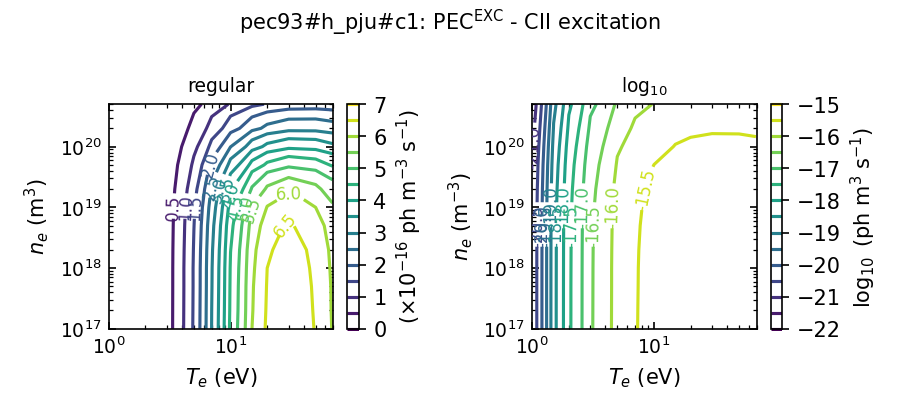

In [26]:
cmap=plt.cm.viridis

fig, ax = plt.subplots(1, 2, figsize=(6,2.75), dpi=150)


N = 16
levels = np.linspace(0., 7e-16*(10**N), 15)
cf = ax[0].contour(TeCarbon, neCarbon, dataExciteCarbon*(10**N), levels, cmap=cmap)
fig.colorbar(
    cf, ax=ax[0], ticks=levels[::2], 
    label=f'($\\times10^{{{-N:.0f}}}$ ph m$^{{-3}}$ s$^{{-1}}$)'
)
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].clabel(
    cf, inline=1, fontsize=8, fmt='%1.1f', inline_spacing=5, use_clabeltext=False
)
ax[0].set_xlabel('$T_e$ (eV)')
ax[0].set_ylabel('$n_e$ (m$^3$)')
ax[0].set_xlim([1e0,70.])
ax[0].set_ylim([1e17,5e20])
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].set_title('regular', fontsize=9)


levels = np.linspace(-22, -15, 15)
cf = ax[1].contour(TeCarbon, neCarbon, np.log10(dataExciteCarbon), levels, cmap=cmap)
fig.colorbar(
    cf, ax=ax[1], ticks=levels[::2], 
    label='$\\log_{10}$ (ph m$^3$ s$^{-1}$)'
)
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].clabel(
    cf, inline=1, fontsize=8, fmt='%1.1f', inline_spacing=10, use_clabeltext=False
)
ax[1].set_xlabel('$T_e$ (eV)')
ax[1].set_ylabel('$n_e$ (m$^{-3}$)')
ax[1].set_xlim([1e0,70.])
ax[1].set_ylim([1e17,5e20])
ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].set_title('$\\log_{10}$', fontsize=9)

fig.suptitle('pec93#h_pju#c1: PEC$^\\mathrm{EXC}$ - CII excitation', fontsize=10)
plt.tight_layout()

/tmp/ipykernel_19920/3584456118.py:2: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For scattered data, prefer `LinearNDInterpolator` or
`CloughTocher2DInterpolator`.

For more details see
`https://scipy.github.io/devdocs/notebooks/interp_transition_guide.html`

  fExciteCarbonLinear = interp2d(TeCarbon, neCarbon, dataExciteCarbon, kind='linear', bounds_error=False)
/tmp/ipykernel_19920/3584456118.py:3: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.

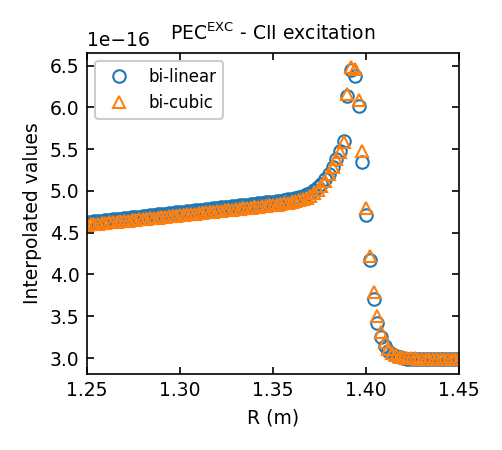

In [27]:
### excitation
fExciteCarbonLinear = interp2d(TeCarbon, neCarbon, dataExciteCarbon, kind='linear', bounds_error=False)
fExciteCarbonCubic = interp2d(TeCarbon, neCarbon, dataExciteCarbon, kind='cubic', bounds_error=False)

exciteCarbonLinear = np.diag(fExciteCarbonLinear(profileTemp, profileDensity))[::-1]
exciteCarbonCubic = np.diag(fExciteCarbonCubic(profileTemp, profileDensity))[::-1]


fig, ax = plt.subplots(1, 1, figsize=(3.35,3), dpi=150)
ax.plot(R, exciteCarbonLinear, 'o', c='C0', mfc='None', label='bi-linear')
ax.plot(R, exciteCarbonCubic, '^', c='C1', mfc='None', label='bi-cubic')
ax.set_title('PEC$^\\mathrm{EXC}$ - CII excitation', fontsize=9)
ax.legend(fancybox=1, framealpha=1, fontsize=8)
ax.set_xlabel('R (m)', fontsize=9)
ax.set_ylabel('Interpolated values', fontsize=9)
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.yaxis.get_offset_text().set_size(9)
ax.set_xlim([R0, R1])
plt.tight_layout()

## 

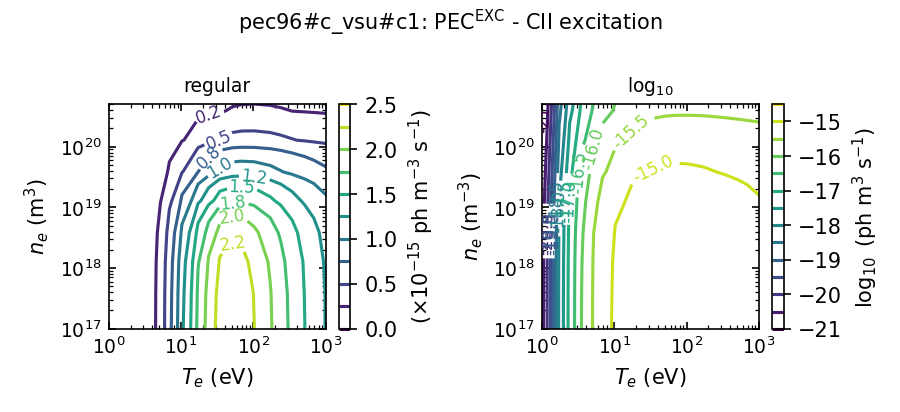

In [28]:
cmap=plt.cm.viridis

fig, ax = plt.subplots(1, 2, figsize=(6,2.75), dpi=150)


N = 15
levels = np.linspace(0., 2.5e-15*(10**N), 11)
cf = ax[0].contour(TeCarbon2, neCarbon2, dataExciteCarbon2*(10**N), levels, cmap=cmap)
fig.colorbar(
    cf, ax=ax[0], ticks=levels[::2], 
    label=f'($\\times10^{{{-N:.0f}}}$ ph m$^{{-3}}$ s$^{{-1}}$)'
)
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].clabel(
    cf, inline=1, fontsize=8, fmt='%1.1f', inline_spacing=5, use_clabeltext=False
)
ax[0].set_xlabel('$T_e$ (eV)')
ax[0].set_ylabel('$n_e$ (m$^3$)')
ax[0].set_xlim([1e0,1e3])
ax[0].set_ylim([1e17,5e20])
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].set_title('regular', fontsize=9)


levels = np.linspace(-21, -14.5, 14)
cf = ax[1].contour(TeCarbon2, neCarbon2, np.log10(dataExciteCarbon2), levels, cmap=cmap)
fig.colorbar(
    cf, ax=ax[1], ticks=levels[::2], 
    label='$\\log_{10}$ (ph m$^3$ s$^{-1}$)'
)
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].clabel(
    cf, inline=1, fontsize=8, fmt='%1.1f', inline_spacing=10, use_clabeltext=False
)
ax[1].set_xlabel('$T_e$ (eV)')
ax[1].set_ylabel('$n_e$ (m$^{-3}$)')
ax[1].set_xlim([1e0,1e3])
ax[1].set_ylim([1e17,5e20])
ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].set_title('$\\log_{10}$', fontsize=9)

fig.suptitle('pec96#c_vsu#c1: PEC$^\\mathrm{EXC}$ - CII excitation', fontsize=10)
plt.tight_layout()

/tmp/ipykernel_19920/185862270.py:2: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For scattered data, prefer `LinearNDInterpolator` or
`CloughTocher2DInterpolator`.

For more details see
`https://scipy.github.io/devdocs/notebooks/interp_transition_guide.html`

  fExciteCarbon2Linear = interp2d(TeCarbon2, neCarbon2, dataExciteCarbon2, kind='linear', bounds_error=True)
/tmp/ipykernel_19920/185862270.py:3: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead

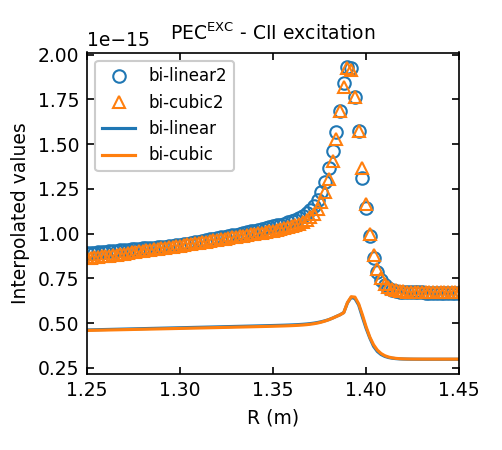

In [29]:
### excitation
fExciteCarbon2Linear = interp2d(TeCarbon2, neCarbon2, dataExciteCarbon2, kind='linear', bounds_error=True)
fExciteCarbon2Cubic = interp2d(TeCarbon2, neCarbon2, dataExciteCarbon2, kind='cubic', bounds_error=True)

exciteCarbon2Linear = np.diag(fExciteCarbon2Linear(profileTemp, profileDensity))[::-1]
exciteCarbon2Cubic = np.diag(fExciteCarbon2Cubic(profileTemp, profileDensity))[::-1]


fig, ax = plt.subplots(1, 1, figsize=(3.35,3), dpi=150)
ax.plot(R, exciteCarbon2Linear, 'o', c='C0', mfc='None', label='bi-linear2')
ax.plot(R, exciteCarbon2Cubic, '^', c='C1', mfc='None', label='bi-cubic2')
ax.plot(R, exciteCarbonLinear, '-', c='C0', mfc='None', label='bi-linear')
ax.plot(R, exciteCarbonCubic, '-', c='C1', mfc='None', label='bi-cubic')
ax.set_title('PEC$^\\mathrm{EXC}$ - CII excitation', fontsize=9)
ax.legend(fancybox=1, framealpha=1, fontsize=8)
ax.set_xlabel('R (m)', fontsize=9)
ax.set_ylabel('Interpolated values', fontsize=9)
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.yaxis.get_offset_text().set_size(9)
ax.set_xlim([R0, R1])
plt.tight_layout()

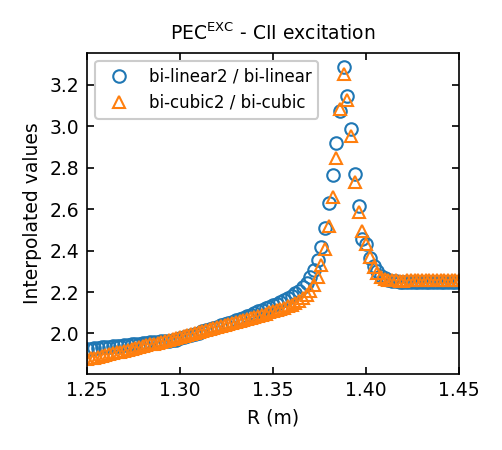

In [30]:
fig, ax = plt.subplots(1, 1, figsize=(3.35,3), dpi=150)
ax.plot(R, exciteCarbon2Linear / exciteCarbonLinear, 'o', c='C0', mfc='None', label='bi-linear2 / bi-linear')
ax.plot(R, exciteCarbon2Cubic / exciteCarbonCubic, '^', c='C1', mfc='None', label='bi-cubic2 / bi-cubic')
ax.set_title('PEC$^\\mathrm{EXC}$ - CII excitation', fontsize=9)
ax.legend(fancybox=1, framealpha=1, fontsize=8)
ax.set_xlabel('R (m)', fontsize=9)
ax.set_ylabel('Interpolated values', fontsize=9)
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.yaxis.get_offset_text().set_size(9)
ax.set_xlim([R0, R1])
plt.tight_layout()

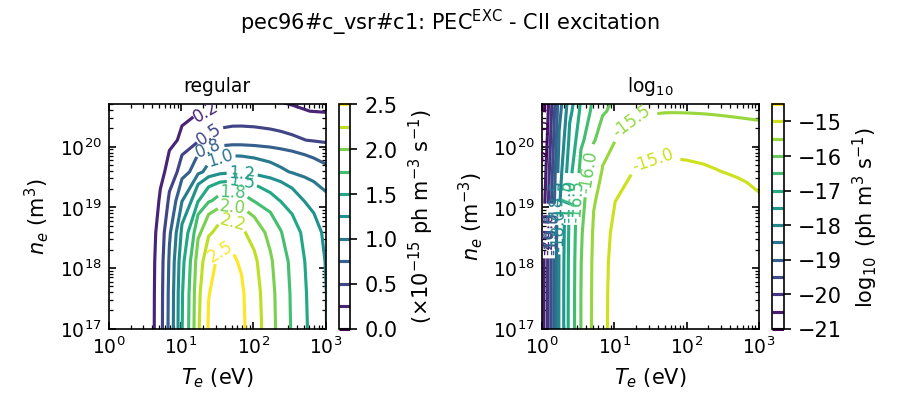

In [31]:
cmap=plt.cm.viridis

fig, ax = plt.subplots(1, 2, figsize=(6,2.75), dpi=150)


N = 15
levels = np.linspace(0., 2.5e-15*(10**N), 11)
cf = ax[0].contour(TeCarbon3, neCarbon3, dataExciteCarbon3*(10**N), levels, cmap=cmap)
fig.colorbar(
    cf, ax=ax[0], ticks=levels[::2], 
    label=f'($\\times10^{{{-N:.0f}}}$ ph m$^{{-3}}$ s$^{{-1}}$)'
)
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].clabel(
    cf, inline=1, fontsize=8, fmt='%1.1f', inline_spacing=5, use_clabeltext=False
)
ax[0].set_xlabel('$T_e$ (eV)')
ax[0].set_ylabel('$n_e$ (m$^3$)')
ax[0].set_xlim([1e0,1e3])
ax[0].set_ylim([1e17,5e20])
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].set_title('regular', fontsize=9)


levels = np.linspace(-21, -14.5, 14)
cf = ax[1].contour(TeCarbon3, neCarbon3, np.log10(dataExciteCarbon3), levels, cmap=cmap)
fig.colorbar(
    cf, ax=ax[1], ticks=levels[::2], 
    label='$\\log_{10}$ (ph m$^3$ s$^{-1}$)'
)
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].clabel(
    cf, inline=1, fontsize=8, fmt='%1.1f', inline_spacing=10, use_clabeltext=False
)
ax[1].set_xlabel('$T_e$ (eV)')
ax[1].set_ylabel('$n_e$ (m$^{-3}$)')
ax[1].set_xlim([1e0,1e3])
ax[1].set_ylim([1e17,5e20])
ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].set_title('$\\log_{10}$', fontsize=9)

fig.suptitle('pec96#c_vsr#c1: PEC$^\\mathrm{EXC}$ - CII excitation', fontsize=10)
plt.tight_layout()

/tmp/ipykernel_19920/3800507903.py:2: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For scattered data, prefer `LinearNDInterpolator` or
`CloughTocher2DInterpolator`.

For more details see
`https://scipy.github.io/devdocs/notebooks/interp_transition_guide.html`

  fExciteCarbon3Linear = interp2d(TeCarbon3, neCarbon3, dataExciteCarbon3, kind='linear', bounds_error=True)
/tmp/ipykernel_19920/3800507903.py:3: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` inste

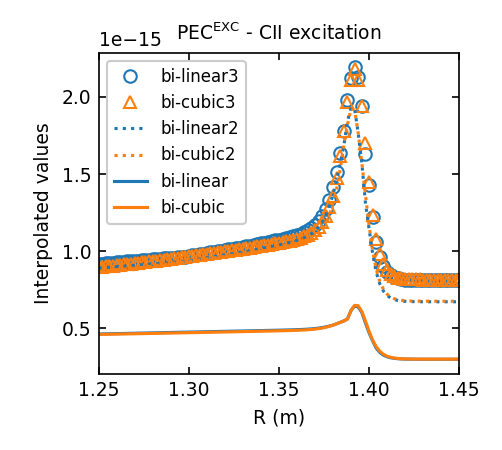

In [32]:
### excitation
fExciteCarbon3Linear = interp2d(TeCarbon3, neCarbon3, dataExciteCarbon3, kind='linear', bounds_error=True)
fExciteCarbon3Cubic = interp2d(TeCarbon3, neCarbon3, dataExciteCarbon3, kind='cubic', bounds_error=True)

exciteCarbon3Linear = np.diag(fExciteCarbon3Linear(profileTemp, profileDensity))[::-1]
exciteCarbon3Cubic = np.diag(fExciteCarbon3Cubic(profileTemp, profileDensity))[::-1]


fig, ax = plt.subplots(1, 1, figsize=(3.35,3), dpi=150)
ax.plot(R, exciteCarbon3Linear, 'o', c='C0', mfc='None', label='bi-linear3')
ax.plot(R, exciteCarbon3Cubic, '^', c='C1', mfc='None', label='bi-cubic3')
ax.plot(R, exciteCarbon2Linear, ':', c='C0', mfc='None', label='bi-linear2')
ax.plot(R, exciteCarbon2Cubic, ':', c='C1', mfc='None', label='bi-cubic2')
ax.plot(R, exciteCarbonLinear, '-', c='C0', mfc='None', label='bi-linear')
ax.plot(R, exciteCarbonCubic, '-', c='C1', mfc='None', label='bi-cubic')
ax.set_title('PEC$^\\mathrm{EXC}$ - CII excitation', fontsize=9)
ax.legend(fancybox=1, framealpha=1, fontsize=8)
ax.set_xlabel('R (m)', fontsize=9)
ax.set_ylabel('Interpolated values', fontsize=9)
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.yaxis.get_offset_text().set_size(9)
ax.set_xlim([R0, R1])
plt.tight_layout()

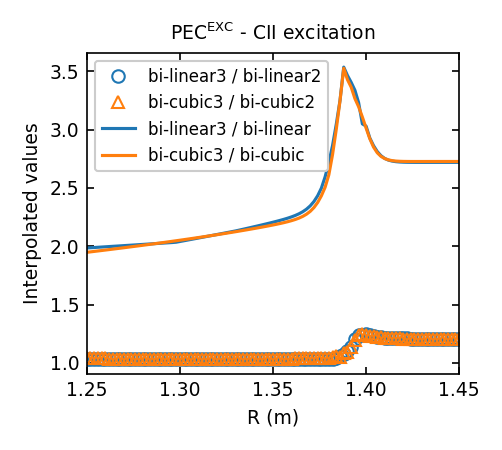

In [33]:
fig, ax = plt.subplots(1, 1, figsize=(3.35,3), dpi=150)
ax.plot(R, exciteCarbon3Linear / exciteCarbon2Linear, 'o', c='C0', mfc='None', label='bi-linear3 / bi-linear2')
ax.plot(R, exciteCarbon3Cubic / exciteCarbon2Cubic, '^', c='C1', mfc='None', label='bi-cubic3 / bi-cubic2')
ax.plot(R, exciteCarbon3Linear / exciteCarbonLinear, '-', c='C0', mfc='None', label='bi-linear3 / bi-linear')
ax.plot(R, exciteCarbon3Cubic / exciteCarbonCubic, '-', c='C1', mfc='None', label='bi-cubic3 / bi-cubic')
ax.set_title('PEC$^\\mathrm{EXC}$ - CII excitation', fontsize=9)
ax.legend(fancybox=1, framealpha=1, fontsize=8)
ax.set_xlabel('R (m)', fontsize=9)
ax.set_ylabel('Interpolated values', fontsize=9)
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.yaxis.get_offset_text().set_size(9)
ax.set_xlim([R0, R1])
plt.tight_layout()

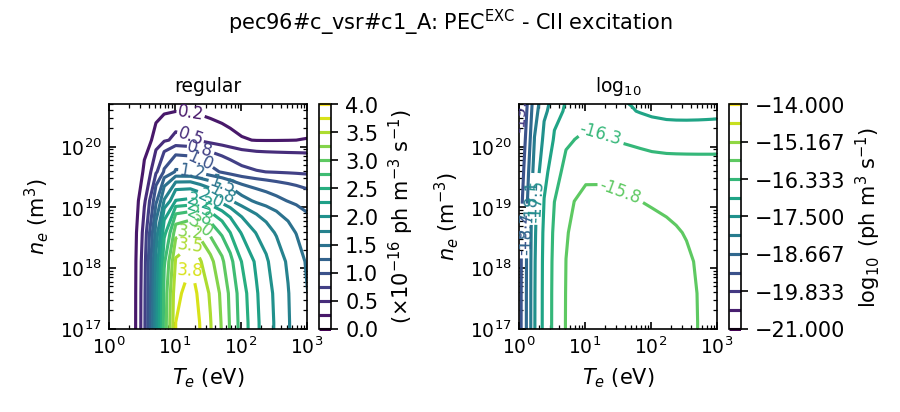

In [34]:
cmap=plt.cm.viridis

fig, ax = plt.subplots(1, 2, figsize=(6,2.75), dpi=150)


N = 16
levels = np.linspace(0., 4e-16*(10**N), 17)
cf = ax[0].contour(TeCarbon3A, neCarbon3A, dataExciteCarbon3A*(10**N), levels, cmap=cmap)
fig.colorbar(
    cf, ax=ax[0], ticks=levels[::2], 
    label=f'($\\times10^{{{-N:.0f}}}$ ph m$^{{-3}}$ s$^{{-1}}$)'
)
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].clabel(
    cf, inline=1, fontsize=8, fmt='%1.1f', inline_spacing=5, use_clabeltext=False
)
ax[0].set_xlabel('$T_e$ (eV)')
ax[0].set_ylabel('$n_e$ (m$^3$)')
ax[0].set_xlim([1e0,1e3])
ax[0].set_ylim([1e17,5e20])
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].set_title('regular', fontsize=9)


levels = np.linspace(-21, -14., 13)
cf = ax[1].contour(TeCarbon3A, neCarbon3A, np.log10(dataExciteCarbon3A), levels, cmap=cmap)
fig.colorbar(
    cf, ax=ax[1], ticks=levels[::2], 
    label='$\\log_{10}$ (ph m$^3$ s$^{-1}$)'
)
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].clabel(
    cf, inline=1, fontsize=8, fmt='%1.1f', inline_spacing=10, use_clabeltext=False
)
ax[1].set_xlabel('$T_e$ (eV)')
ax[1].set_ylabel('$n_e$ (m$^{-3}$)')
ax[1].set_xlim([1e0,1e3])
ax[1].set_ylim([1e17,5e20])
ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].set_title('$\\log_{10}$', fontsize=9)

fig.suptitle('pec96#c_vsr#c1_A: PEC$^\\mathrm{EXC}$ - CII excitation', fontsize=10)
plt.tight_layout()

/tmp/ipykernel_19920/429056905.py:2: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For scattered data, prefer `LinearNDInterpolator` or
`CloughTocher2DInterpolator`.

For more details see
`https://scipy.github.io/devdocs/notebooks/interp_transition_guide.html`

  fExciteCarbon3ALinear = interp2d(TeCarbon3A, neCarbon3A, dataExciteCarbon3A, kind='linear', bounds_error=True)
/tmp/ipykernel_19920/429056905.py:3: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` ins

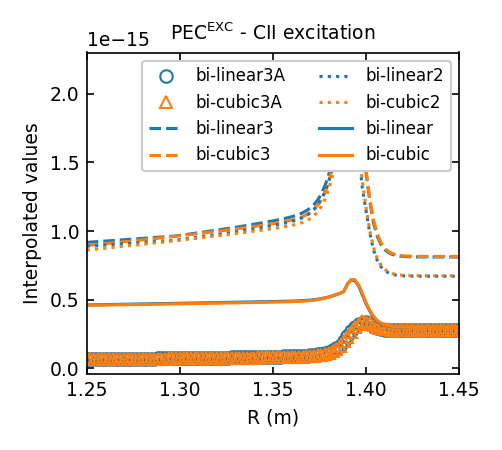

In [35]:
### excitation
fExciteCarbon3ALinear = interp2d(TeCarbon3A, neCarbon3A, dataExciteCarbon3A, kind='linear', bounds_error=True)
fExciteCarbon3ACubic = interp2d(TeCarbon3A, neCarbon3A, dataExciteCarbon3A, kind='cubic', bounds_error=True)

exciteCarbon3ALinear = np.diag(fExciteCarbon3ALinear(profileTemp, profileDensity))[::-1]
exciteCarbon3ACubic = np.diag(fExciteCarbon3ACubic(profileTemp, profileDensity))[::-1]


fig, ax = plt.subplots(1, 1, figsize=(3.35,3), dpi=150)
ax.plot(R, exciteCarbon3ALinear, 'o', c='C0', mfc='None', label='bi-linear3A')
ax.plot(R, exciteCarbon3ACubic, '^', c='C1', mfc='None', label='bi-cubic3A')
ax.plot(R, exciteCarbon3Linear, '--', c='C0', mfc='None', label='bi-linear3')
ax.plot(R, exciteCarbon3Cubic, '--', c='C1', mfc='None', label='bi-cubic3')
ax.plot(R, exciteCarbon2Linear, ':', c='C0', mfc='None', label='bi-linear2')
ax.plot(R, exciteCarbon2Cubic, ':', c='C1', mfc='None', label='bi-cubic2')
ax.plot(R, exciteCarbonLinear, '-', c='C0', mfc='None', label='bi-linear')
ax.plot(R, exciteCarbonCubic, '-', c='C1', mfc='None', label='bi-cubic')
ax.set_title('PEC$^\\mathrm{EXC}$ - CII excitation', fontsize=9)
ax.legend(fancybox=1, framealpha=1, fontsize=8, ncol=2)
ax.set_xlabel('R (m)', fontsize=9)
ax.set_ylabel('Interpolated values', fontsize=9)
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.yaxis.get_offset_text().set_size(9)
ax.set_xlim([R0, R1])
plt.tight_layout()

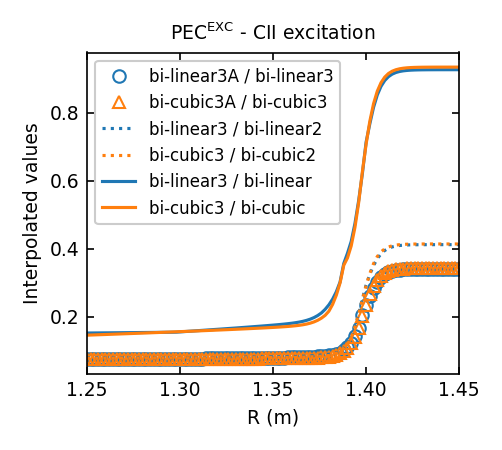

In [36]:
fig, ax = plt.subplots(1, 1, figsize=(3.35,3), dpi=150)
ax.plot(R, exciteCarbon3ALinear / exciteCarbon3Linear, 'o', c='C0', mfc='None', label='bi-linear3A / bi-linear3')
ax.plot(R, exciteCarbon3ACubic / exciteCarbon3Cubic, '^', c='C1', mfc='None', label='bi-cubic3A / bi-cubic3')
ax.plot(R, exciteCarbon3ALinear / exciteCarbon2Linear, ':', c='C0', mfc='None', label='bi-linear3 / bi-linear2')
ax.plot(R, exciteCarbon3ACubic / exciteCarbon2Cubic, ':', c='C1', mfc='None', label='bi-cubic3 / bi-cubic2')
ax.plot(R, exciteCarbon3ALinear / exciteCarbonLinear, '-', c='C0', mfc='None', label='bi-linear3 / bi-linear')
ax.plot(R, exciteCarbon3ACubic / exciteCarbonCubic, '-', c='C1', mfc='None', label='bi-cubic3 / bi-cubic')
ax.set_title('PEC$^\\mathrm{EXC}$ - CII excitation', fontsize=9)
ax.legend(fancybox=1, framealpha=1, fontsize=8)
ax.set_xlabel('R (m)', fontsize=9)
ax.set_ylabel('Interpolated values', fontsize=9)
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.yaxis.get_offset_text().set_size(9)
ax.set_xlim([R0, R1])
plt.tight_layout()

/tmp/ipykernel_19920/799618749.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1, 2, figsize=(5.35,3), dpi=150)


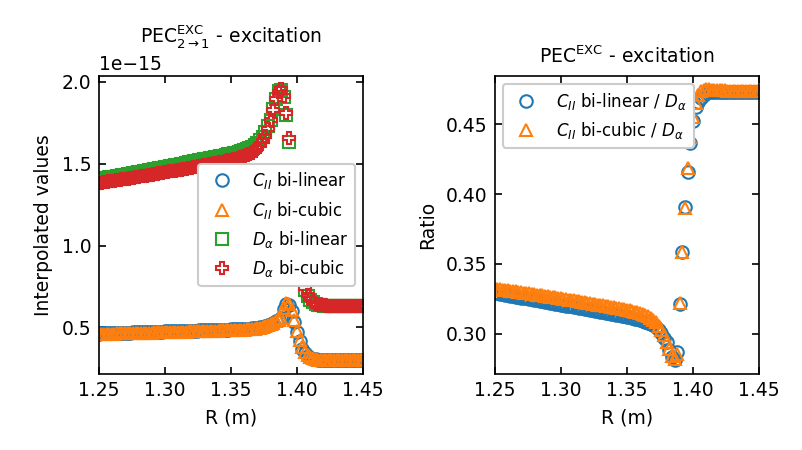

In [37]:
fig, ax = plt.subplots(1, 2, figsize=(5.35,3), dpi=150)

ax[0].plot(R, exciteCarbonLinear, 'o', c='C0', mfc='None', label='$C_{II}$ bi-linear')
ax[0].plot(R, exciteCarbonCubic, '^', c='C1', mfc='None', label='$C_{II}$ bi-cubic')
ax[0].plot(R, exciteLinear, 's', c='C2', mfc='None', label='$D_\\alpha$ bi-linear')
ax[0].plot(R, exciteCubic, 'P', c='C3', mfc='None', label='$D_\\alpha$ bi-cubic')
ax[0].set_title('PEC$^\\mathrm{EXC}_{2 \\rightarrow 1}$ - excitation', fontsize=9)
ax[0].legend(fancybox=1, framealpha=1, fontsize=8)
ax[0].set_xlabel('R (m)', fontsize=9)
ax[0].set_ylabel('Interpolated values', fontsize=9)
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].yaxis.get_offset_text().set_size(9)
ax[0].set_xlim([R0, R1])

ax[1].plot(R, exciteCarbonLinear / exciteLinear, 'o', c='C0', mfc='None', label='$C_{II}$ bi-linear / $D_\\alpha$')
ax[1].plot(R, exciteCarbonCubic / exciteCubic, '^', c='C1', mfc='None', label='$C_{II}$ bi-cubic / $D_\\alpha$')
ax[1].set_title('PEC$^\\mathrm{EXC}$ - excitation', fontsize=9)
ax[1].legend(fancybox=1, framealpha=1, fontsize=8)
ax[1].set_xlabel('R (m)', fontsize=9)
ax[1].set_ylabel('Ratio', fontsize=9)
ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].yaxis.get_offset_text().set_size(9)
ax[1].set_xlim([R0, R1])

plt.tight_layout()

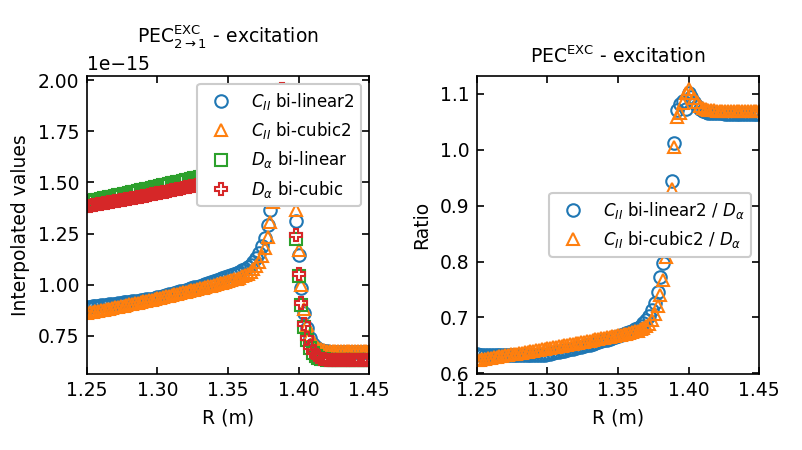

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(5.35,3), dpi=150)

ax[0].plot(R, exciteCarbon2Linear, 'o', c='C0', mfc='None', label='$C_{II}$ bi-linear2')
ax[0].plot(R, exciteCarbon2Cubic, '^', c='C1', mfc='None', label='$C_{II}$ bi-cubic2')
ax[0].plot(R, exciteLinear, 's', c='C2', mfc='None', label='$D_\\alpha$ bi-linear')
ax[0].plot(R, exciteCubic, 'P', c='C3', mfc='None', label='$D_\\alpha$ bi-cubic')
ax[0].set_title('PEC$^\\mathrm{EXC}_{2 \\rightarrow 1}$ - excitation', fontsize=9)
ax[0].legend(fancybox=1, framealpha=1, fontsize=8)
ax[0].set_xlabel('R (m)', fontsize=9)
ax[0].set_ylabel('Interpolated values', fontsize=9)
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].yaxis.get_offset_text().set_size(9)
ax[0].set_xlim([R0, R1])

ax[1].plot(R, exciteCarbon2Linear / exciteLinear, 'o', c='C0', mfc='None', label='$C_{II}$ bi-linear2 / $D_\\alpha$')
ax[1].plot(R, exciteCarbon2Cubic / exciteCubic, '^', c='C1', mfc='None', label='$C_{II}$ bi-cubic2 / $D_\\alpha$')
ax[1].set_title('PEC$^\\mathrm{EXC}$ - excitation', fontsize=9)
ax[1].legend(fancybox=1, framealpha=1, fontsize=8)
ax[1].set_xlabel('R (m)', fontsize=9)
ax[1].set_ylabel('Ratio', fontsize=9)
ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].yaxis.get_offset_text().set_size(9)
ax[1].set_xlim([R0, R1])

plt.tight_layout()

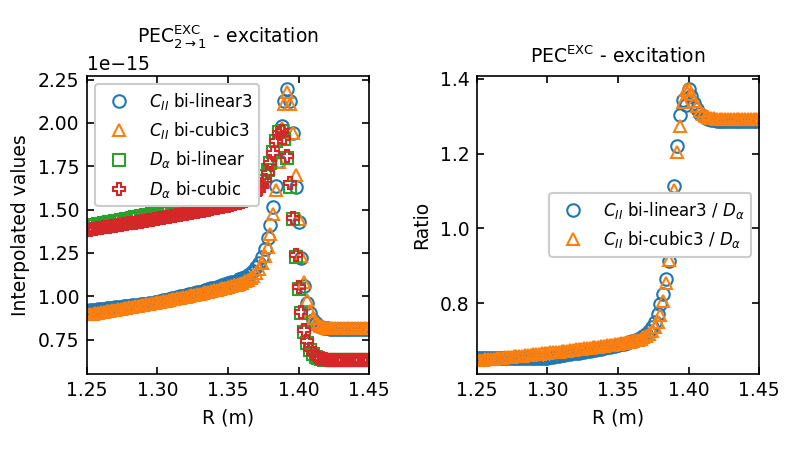

In [39]:
fig, ax = plt.subplots(1, 2, figsize=(5.35,3), dpi=150)

ax[0].plot(R, exciteCarbon3Linear, 'o', c='C0', mfc='None', label='$C_{II}$ bi-linear3')
ax[0].plot(R, exciteCarbon3Cubic, '^', c='C1', mfc='None', label='$C_{II}$ bi-cubic3')
ax[0].plot(R, exciteLinear, 's', c='C2', mfc='None', label='$D_\\alpha$ bi-linear')
ax[0].plot(R, exciteCubic, 'P', c='C3', mfc='None', label='$D_\\alpha$ bi-cubic')
ax[0].set_title('PEC$^\\mathrm{EXC}_{2 \\rightarrow 1}$ - excitation', fontsize=9)
ax[0].legend(fancybox=1, framealpha=1, fontsize=8)
ax[0].set_xlabel('R (m)', fontsize=9)
ax[0].set_ylabel('Interpolated values', fontsize=9)
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].yaxis.get_offset_text().set_size(9)
ax[0].set_xlim([R0, R1])

ax[1].plot(R, exciteCarbon3Linear / exciteLinear, 'o', c='C0', mfc='None', label='$C_{II}$ bi-linear3 / $D_\\alpha$')
ax[1].plot(R, exciteCarbon3Cubic / exciteCubic, '^', c='C1', mfc='None', label='$C_{II}$ bi-cubic3 / $D_\\alpha$')
ax[1].set_title('PEC$^\\mathrm{EXC}$ - excitation', fontsize=9)
ax[1].legend(fancybox=1, framealpha=1, fontsize=8)
ax[1].set_xlabel('R (m)', fontsize=9)
ax[1].set_ylabel('Ratio', fontsize=9)
ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].yaxis.get_offset_text().set_size(9)
ax[1].set_xlim([R0, R1])

plt.tight_layout()

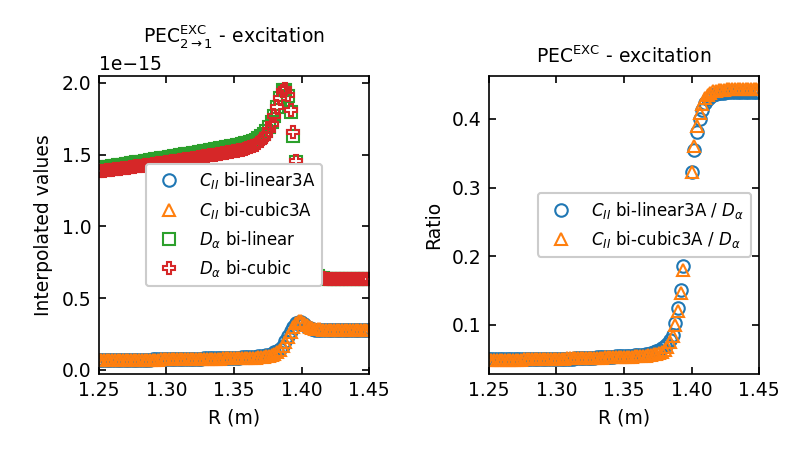

In [40]:
fig, ax = plt.subplots(1, 2, figsize=(5.35,3), dpi=150)

ax[0].plot(R, exciteCarbon3ALinear, 'o', c='C0', mfc='None', label='$C_{II}$ bi-linear3A')
ax[0].plot(R, exciteCarbon3ACubic, '^', c='C1', mfc='None', label='$C_{II}$ bi-cubic3A')
ax[0].plot(R, exciteLinear, 's', c='C2', mfc='None', label='$D_\\alpha$ bi-linear')
ax[0].plot(R, exciteCubic, 'P', c='C3', mfc='None', label='$D_\\alpha$ bi-cubic')
ax[0].set_title('PEC$^\\mathrm{EXC}_{2 \\rightarrow 1}$ - excitation', fontsize=9)
ax[0].legend(fancybox=1, framealpha=1, fontsize=8)
ax[0].set_xlabel('R (m)', fontsize=9)
ax[0].set_ylabel('Interpolated values', fontsize=9)
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].yaxis.get_offset_text().set_size(9)
ax[0].set_xlim([R0, R1])

ax[1].plot(R, exciteCarbon3ALinear / exciteLinear, 'o', c='C0', mfc='None', label='$C_{II}$ bi-linear3A / $D_\\alpha$')
ax[1].plot(R, exciteCarbon3ACubic / exciteCubic, '^', c='C1', mfc='None', label='$C_{II}$ bi-cubic3A / $D_\\alpha$')
ax[1].set_title('PEC$^\\mathrm{EXC}$ - excitation', fontsize=9)
ax[1].legend(fancybox=1, framealpha=1, fontsize=8)
ax[1].set_xlabel('R (m)', fontsize=9)
ax[1].set_ylabel('Ratio', fontsize=9)
ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].yaxis.get_offset_text().set_size(9)
ax[1].set_xlim([R0, R1])

plt.tight_layout()

In [41]:
I0 = 239
I1 = 240
J0 = 32
J1 = 216

In [42]:
R0, z0 = HSV.getRz("/home/sthoma/tokamak_inversion_routines/mastu/Coordinates/50499_1037.npz", I0, I1, J0, J1)
R1, z1 = HSV.getRz("/home/sthoma/tokamak_inversion_routines/mastu/Coordinates/50499_1037.npz", I0-1, I1-1, J0, J1)
R2, z2 = HSV.getRz("/home/sthoma/tokamak_inversion_routines/mastu/Coordinates/50499_1037.npz", I0-2, I1-2, J0, J1)
R3, z3 = HSV.getRz("/home/sthoma/tokamak_inversion_routines/mastu/Coordinates/50499_1037.npz", I0-3, I1-3, J0, J1)
R4, z4 = HSV.getRz("/home/sthoma/tokamak_inversion_routines/mastu/Coordinates/50499_1037.npz", I0-4, I1-4, J0, J1)
R5, z5 = HSV.getRz("/home/sthoma/tokamak_inversion_routines/mastu/Coordinates/50499_1037.npz", I0-5, I1-5, J0, J1)

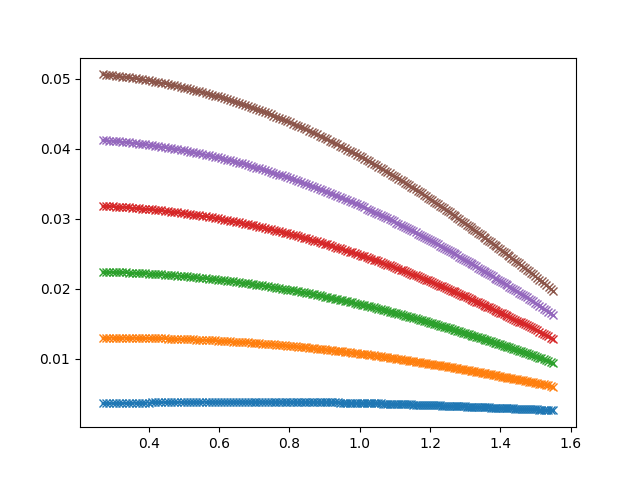

In [43]:
plt.figure()
plt.plot(R0, z0, '-x', label='0')
plt.plot(R1, z1, '-x', label='1')
plt.plot(R2, z2, '-x', label='2')
plt.plot(R3, z3, '-x', label='3')
plt.plot(R4, z4, '-x', label='4')
plt.plot(R5, z5, '-x', label='5')